In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import deque
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F

C_DQN  = "dodgerblue"
C_HEUR = "darkorange"

pi = np.pi

import dqn
import hex_world
import oracle

In [2]:
def sim_instance(
        seed=None,
        model_type="double_DQN",
        sim_len=500000,
        env_kwargs=None,
        hmax = 3,
        smax = 3,
        memory_len=10,
        replay_archive_len=5000,
        n_hidden=64,
        lam = 0.3,
        epsilon_start=0.3,
        gamma=0.98,
        alpha=0.01,
        death_penalty_k=0.5,
        batch_size=512,
        update_ticks=500,
        replay_warmup=500,
        learn_every=20,
        eval_len=20000,
        check_eval_states=False,
        debug_diet_cause = False

):
    
    if env_kwargs is None:
        env_kwargs = dict(radius=3)
        
    if debug_diet_cause:
        print("DIET DEBUG ON")

    if check_eval_states:
        print("CHECK EVAL STATES ON")

    register = {
        "vanilla_DQN" : {
            "fn_make_model" : dqn.vanilla_make_model,
            "fn_make_target" : dqn.vanilla_make_target,
            "fn_sync_target" : dqn.vanilla_sync_target,
            "fn_learn_step" : dqn.vanilla_learn_step,
            "fn_select_action" : dqn.vanilla_select_action
        },

        "double_DQN" : {
            "fn_make_model" : dqn.vanilla_make_model,
            "fn_make_target" : dqn.vanilla_make_target,
            "fn_sync_target" : dqn.vanilla_sync_target,
            "fn_learn_step" : dqn.double_learn_step,
            "fn_select_action" : dqn.vanilla_select_action
        },

        "oracle": {
            "fn_make_model": oracle.make_model,
            "fn_make_target": oracle.make_target,
            "fn_sync_target": oracle.sync_target,
            "fn_learn_step": oracle.learn_step,
            "fn_select_action": oracle.select_action,
        }
    }

    r_model = register[model_type]

    fn_make_model = r_model["fn_make_model"]
    fn_make_target = r_model["fn_make_target"]
    fn_sync_target = r_model["fn_sync_target"]
    fn_learn_step = r_model["fn_learn_step"]
    fn_select_action = r_model["fn_select_action"]

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)

    EB = sim_len - eval_len

    world_size = env_kwargs.get("radius")
    env = hex_world.HexWorld(**env_kwargs)

    actual_water_coord = tuple(env.water_coord)
    actual_food_coord = tuple(env.food_coord)

    if model_type == "oracle":
        oracle.configure(
            water_coord=actual_water_coord,
            food_coord=actual_food_coord,
            fill_h=1.7,
            fill_s=1.7,
        )

    eps_start = epsilon_start
    eps_end = 0.05
    eps_decay_ticks = int(0.7 * EB)

    #print("eps_start", eps_start, "eps_end", eps_end, "eps_decay_ticks", eps_decay_ticks, "EB", EB)

    ideal_h = 1
    ideal_s = 1
    day_length = 50 # ticks

    h = ideal_h
    s = ideal_s

    drink_amount = 0.15
    eat_amount = 0.3

    action_effects = np.array([
        [0.0, 0.0, None],   # 0 wait
        [1.0, 0.0, None],   # 1 drink full
        [0.5, 0.0, None],   # 2 drink half
        [0.25, 0.0, None],  # 3 drink quarter
        [0.0, 1.0, None],   # 4 eat full
        [0.0, 0.5, None],   # 5 eat half
        [0.0, 0.25, None],  # 6 eat quarter
        [0.0, 0.0, 0],      # 7 move E
        [0.0, 0.0, 1],      # 8 move NE
        [0.0, 0.0, 2],      # 9 move NW
        [0.0, 0.0, 3],      # 10 move W
        [0.0, 0.0, 4],      # 11 move SW
        [0.0, 0.0, 5],      # 12 move SE
    ], dtype=object)

    positions1 = np.arange(1, 8)
    weights1 = (11 - positions1) ** 2
    proportions1 = weights1 / weights1.sum()

    positions2 = np.arange(1, 11)
    ##weights2 = positions2 ** 2
    proportions2 = positions2 / positions2.sum()

    r_que = deque(maxlen=replay_archive_len)
    m_que_d = deque([0] * memory_len, maxlen=memory_len)
    m_que_e = deque([0] * memory_len, maxlen=memory_len)
    m_que_m = deque([-1] * memory_len, maxlen=memory_len) # -1 means no movement action remembered
    a_que = deque(maxlen=11)

    action_names = [
    "wait",
    "drink_full", "drink_half", "drink_quarter",
    "eat_full", "eat_half", "eat_quarter",
    "move_E", "move_NE", "move_NW", "move_W", "move_SW", "move_SE",
    ]

    debug_food_eval = True
    debug_food_limit = 80
    debug_food_count = 0

    def hex_dist(a, b):
        aq, ar = a
        bq, br = b
        return max(abs(aq - bq), abs(ar - br), abs((-aq - ar) - (-bq - br)))

    death_penalty = -death_penalty_k / (1 - gamma)

    N_ACT = len(action_effects)

    # state = q, r, cube_s, hydration, satiation, brightness, drink memory, eat memory, move memory
    N_INPUT = 6 + memory_len * 3

    carry_x = ()
    carry_act = 0

    model, optimiser = fn_make_model(N_INPUT, n_hidden, N_ACT, lr=alpha)
    target = fn_make_target(model)

    if model_type == "oracle":
        model.set_context(
            coord=tuple(env.coord),
            hydration=h,
            satiation=s,
        )

    lifetime_stats = [[], [], [], [], [], [], [], [], [], []]
    death_events = []

    eval_zeros = [0] * memory_len
    eval_move_zeros = [-1] * memory_len
    eval_states = {
        "thirsty":   np.array([0, 0, 0, 0.2, 1.0, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
        "hungry":    np.array([0, 0, 0, 1.0, 0.2, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
        "desperate": np.array([0, 0, 0, 0.2, 0.2, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
        "overfull":  np.array([0, 0, 0, 1.5, 1.5, 0.5, *eval_zeros, *eval_zeros, *eval_move_zeros], dtype=np.float32),
    }

    def get_brightness(time, day_len=100):
        a = 0.5
        b = 0.3
        c = (2*pi) / day_len

        brightness = a + b*np.sin(c*time)
        brightness += np.random.normal(0, 0.05)
        return min(1, max(0, brightness))
    
    hydration_decay_scaling = 0.05 + 1.45 / ((1 + 1.0426*(world_size-1))**0.7122)
    satiation_decay_scaling = 0.85 * hydration_decay_scaling

    #print(world_size, hydration_decay_scaling, satiation_decay_scaling)

    def decay_hydration(hydration, satiation, brightness):
        decay = max(0, (0.15*brightness) - (0.03*satiation))
        decay += np.random.normal(0.05, 0.03)
        return hydration - decay * hydration_decay_scaling

    def decay_satiation(satiation, hydration, brightness):
        decay = max(0, ((0.05 - 0.05*brightness) + (0.04 - 0.04*hydration) + 0.1*(ideal_h - hydration)))        
        decay += np.random.normal(0.01, 0.005)
        return satiation - decay * satiation_decay_scaling

    def the_meaning_of_life(hydration, satiation):

        h_over = max(0, hydration - ideal_h)
        h_under = min(0, hydration - ideal_h)

        s_over = max(0, satiation - ideal_s)
        s_under = min(0, satiation - ideal_s)

        d2 = h_under**2 + lam * h_over**2 + s_under**2 + lam * s_over**2

        return 2 * np.exp(-3 * d2) - 1
    
        
        h_dist = hydration - ideal_h
        s_dist = satiation - ideal_s

        d2 = h_dist**2 + s_dist**2

        return 2 * np.exp(-3 * d2) - 1

############################################################ PHSYICAL WORLD INIT ############################
  
    for t in range(sim_len): ######################### SIM LOOP ########################
        b = get_brightness(t, day_length)
        h = decay_hydration(h, s, b)
        s = decay_satiation(s, h, b)

        for age, act in enumerate(a_que):
            drink_choice, eat_choice, move_choice = action_effects[act]

            if age == 0:
                env.apply_action_movement(act) # movement is handled by the physical world now

            if age < len(proportions1):
                h += drink_amount * drink_choice * proportions1[age] * (0.8 + 0.3*s) 

            if age < len(proportions2):
                s += eat_amount * eat_choice * proportions2[age]

        h = min(hmax, max(0, h))
        s = min(smax, max(0, s))

        cur_comfort = the_meaning_of_life(h, s)
        cur_dead = int((h <= 0.05) or (s <= 0.05))
        cur_reward = cur_comfort + death_penalty * cur_dead


        if cur_dead and t != 0:
            if h <= 0.05 and s <= 0.05:
                death_cause = "both"
            elif h <= 0.05:
                death_cause = "hydration"
            else:
                death_cause = "satiation"

            death_events.append({
                "t": t,
                "cause": death_cause,
                "h": h,
                "s": s,
            })

        cur_x = env.make_state(h, s, b, m_que_d, m_que_e, m_que_m)
        cur_mask = env.get_action_mask()

        if t != 0 and t < EB and model_type != "oracle": # dont learn if we dont know anything
            r_que.append((carry_x, carry_act, cur_reward, cur_x, bool(cur_dead), cur_mask))

            if t % learn_every == 0 and len(r_que) >= replay_warmup:
                if t % (update_ticks * learn_every) == 0:
                    fn_sync_target(target, model)

                batch = random.sample(r_que, min(batch_size, len(r_que)))

                fn_learn_step(model, target, optimiser, batch, gamma)

        
        log_coord = tuple(env.coord)
        log_h = h
        log_s = s
        log_m_d = list(m_que_d)
        log_m_e = list(m_que_e)
        log_m_m = list(m_que_m)

        if debug_diet_cause and t >= EB:
            food_coord_tuple = tuple(env_kwargs.get("food_coord", (1, 0)))
            dist_to_food_log = hex_dist(tuple(env.coord), food_coord_tuple)

            if dist_to_food_log <= 1:
                print("\nPRE-RESET FOOD DEBUG")
                print("t:", t, "eval_tick:", t - EB)
                print("coord:", tuple(env.coord), "food:", food_coord_tuple, "dist:", dist_to_food_log)
                print("h, s:", round(float(h), 4), round(float(s), 4))
                print("cur_dead:", cur_dead, "cur_reward:", round(float(cur_reward), 4))
                print("mask:", [(i, action_names[i]) for i in np.flatnonzero(cur_mask)])

        if cur_dead:
            angle = np.random.uniform(0, 2*np.pi)
            radius = np.sqrt(np.random.uniform(0.3**2, 0.6**2))   # note to self i should take jacobian if i want even distrbution
            h = ideal_h + radius * np.cos(angle)
            s = ideal_s + radius * np.sin(angle)

            env.reset_position()

            a_que.clear()
            m_que_d.clear()
            m_que_e.clear()
            m_que_m.clear()

            m_que_d.extend([0] * memory_len)
            m_que_e.extend([0] * memory_len)
            m_que_m.extend([-1] * memory_len)

            cur_x = env.make_state(h, s, b, m_que_d, m_que_e, m_que_m)
            cur_mask = env.get_action_mask()

        if t < EB:
            frac = min(1.0, t / eps_decay_ticks)
            epsilon_t = eps_start + frac * (eps_end - eps_start)
        else:
            epsilon_t = 0.0

        # DEBUG: inspect what the greedy policy wants to do near food during eval
        if debug_food_eval and t >= EB and debug_food_count < debug_food_limit and debug_diet_cause:
            decision_coord = tuple(env.coord)
            food_coord_tuple = tuple(env_kwargs.get("food_coord", (1, 0)))

            # on food or adjacent to food
            if hex_dist(decision_coord, food_coord_tuple) <= 1:
                with torch.no_grad():
                    x_dbg = torch.as_tensor(cur_x, dtype=torch.float32)
                    q_dbg = model(x_dbg).detach().cpu().numpy()

                mask_dbg = np.asarray(cur_mask, dtype=bool)
                q_masked_dbg = q_dbg.copy()
                q_masked_dbg[~mask_dbg] = -1e9

                chosen_dbg = int(np.argmax(q_masked_dbg))
                valid_actions_dbg = np.flatnonzero(mask_dbg)

                top_actions = sorted(
                    [(i, action_names[i], float(q_masked_dbg[i])) for i in range(len(q_masked_dbg))],
                    key=lambda z: z[2],
                    reverse=True
                )[:6]

                print("\nFOOD DEBUG")
                print("t:", t, "eval_tick:", t - EB)
                print("coord:", decision_coord, "food:", food_coord_tuple, "dist:", hex_dist(decision_coord, food_coord_tuple))
                print("h, s:", round(float(h), 4), round(float(s), 4))
                print("valid actions:", [(int(i), action_names[int(i)]) for i in valid_actions_dbg])
                print("chosen greedy:", chosen_dbg, action_names[chosen_dbg])
                print("eat valid?:", {action_names[i]: bool(mask_dbg[i]) for i in [4, 5, 6]})
                print("eat Qs:", {action_names[i]: round(float(q_dbg[i]), 4) for i in [4, 5, 6]})
                print("top masked Qs:", [(i, name, round(q, 4)) for i, name, q in top_actions])

                debug_food_count += 1

        if model_type == "oracle":
            model.set_context(
                coord=tuple(env.coord),
                hydration=h,
                satiation=s,
            )
            action = fn_select_action(model, cur_x, cur_mask)

        else:
            if np.random.uniform(0, 1) < epsilon_t:
                valid_actions = np.flatnonzero(cur_mask)
                action = int(np.random.choice(valid_actions))
            else:
                action = fn_select_action(model, cur_x, cur_mask)

        a_que.appendleft(action)

        drink_memory, eat_memory, move_memory = action_effects[action]

        m_que_d.appendleft(float(drink_memory))
        m_que_e.appendleft(float(eat_memory))
        m_que_m.appendleft(-1 if move_memory is None else int(move_memory))

        carry_x = cur_x
        carry_act = action

        lifetime_stats[0].append(cur_comfort)
        lifetime_stats[1].append(action)
        lifetime_stats[2].append([log_m_d, log_m_e, log_m_m])
        lifetime_stats[3].append(log_h)
        lifetime_stats[4].append(log_s)
        lifetime_stats[5].append(b)
        lifetime_stats[7].append(cur_reward)
        lifetime_stats[8].append(cur_dead)
        lifetime_stats[9].append(log_coord)

        if check_eval_states:
            cur_eval_state_q = []
            for name, state in eval_states.items():
                q = model(torch.as_tensor(state, dtype=torch.float32))
                cur_eval_state_q.append(q)
            lifetime_stats[6].append(cur_eval_state_q)

    lifetime_comfort = np.array(lifetime_stats[0])
    lifetime_action = np.array(lifetime_stats[1])
    lifetime_memory = np.array(lifetime_stats[2])
    lifetime_coordinates = np.array(lifetime_stats[9])
    lifetime_hydration = np.array(lifetime_stats[3])
    lifetime_satiation = np.array(lifetime_stats[4])
    lifetime_brightness = np.array(lifetime_stats[5])

    coord_eval = lifetime_coordinates[EB:]

    water_coord = np.array(env.water_coord)
    food_coord = np.array(env.food_coord)

    ticks_at_water_eval = np.all(coord_eval == water_coord, axis=1).sum()
    ticks_at_food_eval = np.all(coord_eval == food_coord, axis=1).sum()

    lifetime_reward = np.array(lifetime_stats[7])
    death_T = np.array(lifetime_stats[8])

    return {
        "comfort_T" :    lifetime_comfort,
        "action_T" :     lifetime_action,
        "memory_T" :     lifetime_memory,
        "coordinates_T": lifetime_coordinates,
        "hydration_T" :  lifetime_hydration,
        "satiation_T" :  lifetime_satiation,
        "brightness_T" : lifetime_brightness,

        "comfort_train" :    lifetime_comfort[ :EB],
        "action_train" :     lifetime_action[ :EB],
        "memory_train" :     lifetime_memory[ :EB],
        "coordinates_train": lifetime_coordinates[ :EB],
        "hydration_train" :  lifetime_hydration[ :EB],
        "satiation_train" :  lifetime_satiation[ :EB],
        "brightness_train" : lifetime_brightness[ :EB],

        "comfort_eval" :    lifetime_comfort[EB: ],
        "action_eval" :     lifetime_action[EB: ],
        "memory_eval" :     lifetime_memory[EB: ],
        "coordinates_eval": coord_eval,
        "hydration_eval" :  lifetime_hydration[EB: ],
        "satiation_eval" :  lifetime_satiation[EB: ],
        "brightness_eval" : lifetime_brightness[EB: ],

        "mean_comfort" :   lifetime_comfort[EB: ].mean(),
        "min_comfort" :    lifetime_comfort[EB: ].min(),
        "std_comfort" :    lifetime_comfort[EB: ].std(),
        "mean_hydration" : lifetime_hydration[EB: ].mean(),
        "mean_satiation" : lifetime_satiation[EB: ].mean(),

        "ticks_at_water_eval" :  ticks_at_water_eval,
        "ticks_at_food_eval" :   ticks_at_food_eval,

        "reward_T": lifetime_reward,
        "reward_train": lifetime_reward[:EB],
        "reward_eval": lifetime_reward[EB:],
        "mean_reward": lifetime_reward[EB:].mean(),
        "min_reward": lifetime_reward[EB:].min(),
        "max_reward": lifetime_reward[EB:].max(),
        "std_reward": lifetime_reward[EB:].std(),

        "death_T" : death_T,
        "death_events": death_events,
        "death_count" : death_T.sum(),
        "death_rate" : death_T.mean(),
        "death_count_eval": death_T[EB:].sum(),
        "death_rate_eval": death_T[EB:].mean(),
    }

In [ ]:
#region ORACLE SANITY RUN — defaults except model_type
print("Running oracle sanity check...")

run = sim_instance(
    model_type="oracle",
    env_kwargs={"radius": 5, "water_coord": (-5, 0), "food_coord": (0, 5)},
)

EB = len(run["comfort_train"])

action_names = [
    "wait",
    "drink_full", "drink_half", "drink_quarter",
    "eat_full", "eat_half", "eat_quarter",
    "move_E", "move_NE", "move_NW", "move_W", "move_SW", "move_SE",
]

print("\nRESULTS")
print("mean comfort:", run["mean_comfort"])
print("mean reward:", run["mean_reward"])
print("eval deaths:", run["death_count_eval"])
print("eval death rate:", run["death_rate_eval"])

print("\nSTATE")
print("mean hydration:", run["mean_hydration"])
print("mean satiation:", run["mean_satiation"])
print("min hydration eval:", run["hydration_eval"].min())
print("min satiation eval:", run["satiation_eval"].min())

print("\nRESOURCE VISITS")
print("ticks at water eval:", run["ticks_at_water_eval"])
print("ticks at food eval:", run["ticks_at_food_eval"])

print("\nACTION COUNTS — EVAL")
eval_actions = run["action_eval"]
vals, counts = np.unique(eval_actions, return_counts=True)

for act, count in sorted(zip(vals, counts), key=lambda x: x[1], reverse=True):
    print(f"{int(act):>2} {action_names[int(act)]:<14} {int(count)}")

print("\nDEATH CAUSES — EVAL")
eval_deaths = [d for d in run["death_events"] if d["t"] >= EB]

cause_counts = {}
for d in eval_deaths:
    cause_counts[d["cause"]] = cause_counts.get(d["cause"], 0) + 1

if cause_counts:
    for cause, count in cause_counts.items():
        print(cause, count)
else:
    print("none")

print("\nCOVERAGE")
coords = run["coordinates_eval"]
print("unique tiles eval:", len(set(map(tuple, coords))))
print("first eval coord:", tuple(coords[0]))
print("last eval coord:", tuple(coords[-1]))
#endregion

In [4]:
#region SWEEP INIT

import time
import pickle
import json
import itertools
import copy
import inspect
from pathlib import Path
import numpy as np


# -----------------------------
# basic utilities
# -----------------------------

def fmt_time(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60

    if h:
        return f"{h}h {m}m {s}s"
    if m:
        return f"{m}m {s}s"
    return f"{s}s"


def repo_root():
    cwd = Path.cwd()
    return next((p for p in [cwd, *cwd.parents] if (p / ".git").exists()), cwd)

PROTOTYPE_DIR = repo_root() / "prototypes" / "03_spatial_robust"

def sweep_dir(experiment_name):
    return PROTOTYPE_DIR / "results" / "sweeps" / experiment_name

def atomic_pickle_dump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")

    with open(tmp, "wb") as f:
        pickle.dump(obj, f)

    tmp.replace(path)


def slugify(x):
    x = str(x)
    bad = [" ", "/", "\\", ":", ";", ",", "=", "(", ")", "[", "]", "{", "}"]
    for b in bad:
        x = x.replace(b, "")
    x = x.replace(".", "p")
    return x


def fmt_value(v):
    if isinstance(v, bool):
        return "T" if v else "F"

    if isinstance(v, int):
        if abs(v) >= 1_000_000:
            if v % 1_000_000 == 0:
                return f"{v // 1_000_000}m"
            return f"{v / 1_000_000:g}m".replace(".", "p")

        if abs(v) >= 1_000:
            return f"{v // 1_000}k"

        return str(v)

    if isinstance(v, float):
        if 0 <= v < 1:
            return f"{int(round(v * 100)):02d}"
        if v.is_integer():
            return str(int(v))
        return f"{v:.3g}".replace(".", "p")

    if isinstance(v, (tuple, list)):
        return "-".join(fmt_value(a) for a in v)

    return slugify(v)


KEY_ABBR = {
    "env.radius": "r",
    "env.water_coord": "w",
    "env.food_coord": "f",

    "sim.sim_len": "len",
    "sim.eval_len": "eval",
    "sim.decay_version": "decay",

    "agent.batch_size": "b",
    "agent.gamma": "g",
    "agent.epsilon_start": "e",
    "agent.alpha": "a",
    "agent.replay_archive_len": "buf",
    "agent.replay_warmup": "wu",
    "agent.update_ticks": "u",
    "agent.learn_every": "le",
    "agent.n_hidden": "h",
}


def make_config_name(overrides):
    if not overrides:
        return "base"

    parts = []
    for key, value in overrides.items():
        abbr = KEY_ABBR.get(key, key.replace(".", "_"))
        parts.append(f"{abbr}{fmt_value(value)}")

    return slugify("__".join(parts))


# -----------------------------
# config system
# -----------------------------

GROUP_MAP = {
    "env": "env_kwargs",
    "sim": "sim_kwargs",
    "agent": "agent_kwargs",
}


def build_config(
    *,
    base_env,
    base_sim,
    base_agent,
    overrides=None,
    name=None,
):
    overrides = overrides or {}

    config = {
        "name": name if name is not None else make_config_name(overrides),
        "env_kwargs": copy.deepcopy(base_env),
        "sim_kwargs": copy.deepcopy(base_sim),
        "agent_kwargs": copy.deepcopy(base_agent),
        "overrides": copy.deepcopy(overrides),
    }

    for dotted_key, value in overrides.items():
        if "." not in dotted_key:
            raise ValueError(
                f"Override key '{dotted_key}' must be prefixed, e.g. "
                f"'sim.sim_len', 'agent.batch_size', or 'env.radius'."
            )

        group, key = dotted_key.split(".", 1)

        if group not in GROUP_MAP:
            raise ValueError(
                f"Unknown override group '{group}' in key '{dotted_key}'. "
                f"Use one of {list(GROUP_MAP)}."
            )

        config[GROUP_MAP[group]][key] = value

    return config


def make_sweep_configs(
    *,
    base_env,
    base_sim,
    base_agent,
    sweep_grid,
):
    """
    sweep_grid example:

    sweep_grid = {
        "sim.sim_len": [300_000, 600_000, 1_000_000],
    }

    or later:

    sweep_grid = {
        "sim.sim_len": [600_000, 1_000_000],
        "agent.batch_size": [32, 64],
    }
    """
    keys = list(sweep_grid.keys())
    value_lists = [list(sweep_grid[k]) for k in keys]

    configs = []

    for values in itertools.product(*value_lists):
        overrides = dict(zip(keys, values))
        configs.append(
            build_config(
                base_env=base_env,
                base_sim=base_sim,
                base_agent=base_agent,
                overrides=overrides,
            )
        )

    return configs


# -----------------------------
# eval helpers / metrics
# -----------------------------

DRINK_IDS = np.array([1, 2, 3])
EAT_IDS = np.array([4, 5, 6])
FULL_EAT_ID = 4
HALF_EAT_ID = 5
QUARTER_EAT_ID = 6
MOVE_MIN_ID = 7


def hex_dist(a, b):
    aq, ar = tuple(a)
    bq, br = tuple(b)

    return max(
        abs(aq - bq),
        abs(ar - br),
        abs((-aq - ar) - (-bq - br)),
    )


def eval_boundary(run):
    if "eval_boundary" in run:
        return int(run["eval_boundary"])

    if "comfort_train" in run:
        return len(run["comfort_train"])

    raise KeyError("Cannot infer eval boundary. Need run['eval_boundary'] or run['comfort_train'].")


def get_eval_array(run, key_T, key_eval=None):
    if key_T in run:
        eb = eval_boundary(run)
        return np.asarray(run[key_T])[eb:]

    if key_eval is not None and key_eval in run:
        return np.asarray(run[key_eval])

    return None


def extract_water_to_food_trips(
    coords_eval,
    death_eval,
    water_coord,
    food_coord,
    max_trip_ticks=300,
):
    water_coord = tuple(water_coord)
    food_coord = tuple(food_coord)

    trips = []
    active = False
    start_t = None
    ticks = 0
    moves = 0

    for t in range(len(coords_eval) - 1):
        cur = tuple(coords_eval[t])
        nxt = tuple(coords_eval[t + 1])

        if death_eval is not None and death_eval[t]:
            if active:
                trips.append({
                    "success": False,
                    "reason": "death",
                    "start": start_t,
                    "end": t,
                    "ticks": ticks,
                    "moves": moves,
                })
            active = False
            continue

        if not active:
            if cur == water_coord and nxt != water_coord:
                active = True
                start_t = t
                ticks = 0
                moves = 0
            else:
                continue

        step_dist = hex_dist(cur, nxt)
        ticks += 1
        moves += step_dist

        if nxt == food_coord:
            trips.append({
                "success": True,
                "reason": "food",
                "start": start_t,
                "end": t + 1,
                "ticks": ticks,
                "moves": moves,
            })
            active = False

        elif nxt == water_coord:
            trips.append({
                "success": False,
                "reason": "returned_water",
                "start": start_t,
                "end": t + 1,
                "ticks": ticks,
                "moves": moves,
            })
            active = False

        elif ticks >= max_trip_ticks:
            trips.append({
                "success": False,
                "reason": "timeout",
                "start": start_t,
                "end": t + 1,
                "ticks": ticks,
                "moves": moves,
            })
            active = False

    return trips


def compute_eval_metrics(run, env_kwargs):
    eb = eval_boundary(run)

    coords_eval = get_eval_array(run, "coordinates_T", "coordinates_eval")
    actions_eval = get_eval_array(run, "action_T", "action_eval")
    death_eval = get_eval_array(run, "death_T", "death_eval")

    if coords_eval is None or actions_eval is None:
        return {}

    coords_eval = np.asarray(coords_eval, dtype=int)
    actions_eval = np.asarray(actions_eval)
    death_eval = np.asarray(death_eval).astype(bool) if death_eval is not None else np.zeros(len(coords_eval), dtype=bool)

    radius = env_kwargs.get("radius", None)

    water_coord = env_kwargs.get("water_coord", None)
    food_coord = env_kwargs.get("food_coord", None)

    if water_coord is None and radius is not None:
        water_coord = (-radius, 0)

    if food_coord is None and radius is not None:
        food_coord = (0, radius)

    metrics = {}

    metrics["eval_len"] = int(len(coords_eval))
    metrics["eval_deaths"] = int(death_eval.sum())

    # non-neighbour jumps check
    # Raw includes death/reset jumps. Clean ignores jumps touching a death tick.
    jumps_raw = 0
    jumps_clean = 0

    for t in range(len(coords_eval) - 1):
        d = hex_dist(coords_eval[t], coords_eval[t + 1])

        if d > 1:
            jumps_raw += 1

            if not (death_eval[t] or death_eval[t + 1]):
                jumps_clean += 1

    metrics["non_neighbor_jumps_raw"] = int(jumps_raw)
    metrics["non_neighbor_jumps"] = int(jumps_clean)

    wait = actions_eval == 0
    drink = np.isin(actions_eval, DRINK_IDS)
    eat = np.isin(actions_eval, EAT_IDS)
    move = actions_eval >= MOVE_MIN_ID

    metrics["wait_rate_eval"] = float(wait.mean())
    metrics["drink_rate_eval"] = float(drink.mean())
    metrics["eat_rate_eval"] = float(eat.mean())
    metrics["move_rate_eval"] = float(move.mean())

    if water_coord is not None:
        water_coord = tuple(water_coord)
        at_water = np.all(coords_eval == water_coord, axis=1)

        metrics["water_coord"] = water_coord
        metrics["water_visit_pct"] = float(100 * at_water.mean())
        metrics["drink_rate_at_water"] = float(drink[at_water].mean()) if at_water.any() else np.nan
        metrics["move_rate_at_water"] = float(move[at_water].mean()) if at_water.any() else np.nan
    else:
        at_water = None

    if food_coord is not None:
        food_coord = tuple(food_coord)
        at_food = np.all(coords_eval == food_coord, axis=1)

        metrics["food_coord"] = food_coord
        metrics["food_visit_pct"] = float(100 * at_food.mean())
        metrics["eat_rate_at_food"] = float(eat[at_food].mean()) if at_food.any() else np.nan
        metrics["full_eat_rate_at_food"] = float((actions_eval[at_food] == FULL_EAT_ID).mean()) if at_food.any() else np.nan
        metrics["half_eat_rate_at_food"] = float((actions_eval[at_food] == HALF_EAT_ID).mean()) if at_food.any() else np.nan
        metrics["quarter_eat_rate_at_food"] = float((actions_eval[at_food] == QUARTER_EAT_ID).mean()) if at_food.any() else np.nan
    else:
        at_food = None

    if water_coord is not None and food_coord is not None:
        shortest = hex_dist(water_coord, food_coord)
        trips = extract_water_to_food_trips(
            coords_eval=coords_eval,
            death_eval=death_eval,
            water_coord=water_coord,
            food_coord=food_coord,
        )

        successful = [tr for tr in trips if tr["success"]]
        success_moves = np.array([tr["moves"] for tr in successful], dtype=float)

        metrics["water_to_food_shortest_dist"] = int(shortest)
        metrics["water_to_food_trip_count"] = int(len(trips))
        metrics["water_to_food_success_count"] = int(len(successful))
        metrics["water_to_food_success_rate"] = float(len(successful) / len(trips)) if trips else np.nan
        metrics["median_success_trip_moves"] = float(np.median(success_moves)) if len(success_moves) else np.nan
        metrics["path_efficiency"] = float(shortest / np.median(success_moves)) if len(success_moves) else np.nan
        metrics["perfectish_trip_rate"] = float((success_moves <= shortest + 1).mean()) if len(success_moves) else np.nan

    return metrics



def effective_kwargs_from_signature(train_fn, config):
    """
    Build the actual saved metadata by reading train_fn defaults,
    then overlaying config kwargs.

    So if sim_instance has gamma=0.98 by default, saved runs will show gamma=0.98
    even if BASE_AGENT does not explicitly contain gamma.
    """
    sig = inspect.signature(train_fn)

    defaults = {}
    for name, p in sig.parameters.items():
        if p.default is not inspect._empty:
            defaults[name] = copy.deepcopy(p.default)

    # Keep this split simple and explicit.
    # These are simulation-control args, not agent hyperparams.
    sim_keys = {
        "sim_len",
        "eval_len",
        "check_eval_states",
    }

    # These should not be saved inside agent_kwargs.
    ignored_keys = {
        "seed",
        "env_kwargs",
        "sim_kwargs",
        "agent_kwargs",
    }

    effective_sim = {
        k: v for k, v in defaults.items()
        if k in sim_keys
    }

    effective_agent = {
        k: v for k, v in defaults.items()
        if k not in sim_keys and k not in ignored_keys
    }

    # Config values override defaults.
    effective_sim.update(copy.deepcopy(config.get("sim_kwargs", {})))
    effective_agent.update(copy.deepcopy(config.get("agent_kwargs", {})))

    return effective_sim, effective_agent

# -----------------------------
# run slimming
# -----------------------------

ARRAY_DTYPES = {
    "comfort_T": np.float32,
    "hydration_T": np.float32,
    "satiation_T": np.float32,
    "death_T": bool,
    "coordinates_T": np.int16,
    "action_T": np.int16,
}

def slim_run(raw_run, config, seed, run_time=None, train_fn=None):
    eb = eval_boundary(raw_run)

    if train_fn is not None:
        effective_sim, effective_agent = effective_kwargs_from_signature(train_fn, config)
    else:
        effective_sim = copy.deepcopy(config["sim_kwargs"])
        effective_agent = copy.deepcopy(config["agent_kwargs"])

    slim = {
        "eval_boundary": eb,
        "seed": int(seed),
        "config_name": config["name"],
        "env_kwargs": copy.deepcopy(config["env_kwargs"]),
        "sim_kwargs": effective_sim,
        "agent_kwargs": effective_agent,
        "overrides": copy.deepcopy(config.get("overrides", {})),
    }

    if run_time is not None:
        slim["run_time_seconds"] = float(run_time)

    for key, dtype in ARRAY_DTYPES.items():
        if key in raw_run:
            slim[key] = np.asarray(raw_run[key]).astype(dtype)

    if "comfort_T" in slim:
        slim["comfort_train"] = slim["comfort_T"][:eb].astype(np.float32)
        slim["comfort_eval"] = slim["comfort_T"][eb:].astype(np.float32)

    if "hydration_T" in slim:
        slim["hydration_eval"] = slim["hydration_T"][eb:].astype(np.float32)

    if "satiation_T" in slim:
        slim["satiation_eval"] = slim["satiation_T"][eb:].astype(np.float32)

    if "mean_comfort" in raw_run:
        slim["mean_comfort"] = float(raw_run["mean_comfort"])
    elif "comfort_eval" in slim:
        slim["mean_comfort"] = float(np.mean(slim["comfort_eval"]))

    if "mean_reward" in raw_run:
        slim["mean_reward"] = float(raw_run["mean_reward"])

    if "death_count_eval" in raw_run:
        slim["death_count_eval"] = int(raw_run["death_count_eval"])
    elif "death_T" in slim:
        slim["death_count_eval"] = int(np.asarray(slim["death_T"][eb:]).sum())

    if "death_rate_eval" in raw_run:
        slim["death_rate_eval"] = float(raw_run["death_rate_eval"])
    elif "death_T" in slim:
        slim["death_rate_eval"] = float(np.asarray(slim["death_T"][eb:]).mean())

    slim["metrics"] = compute_eval_metrics(slim, config["env_kwargs"])

    return slim


# -----------------------------
# calling the training function
# -----------------------------

def call_train_fn(train_fn, config, seed):
    """
    This adapts to two possible sim_instance styles:

    1. New clean style:
       sim_instance(seed=seed, env_kwargs={...}, **sim_kwargs, **agent_kwargs)

    2. Flat old style:
       sim_instance(seed=seed, radius=3, sim_len=..., batch_size=..., etc.)

    It uses the function signature so TypeErrors inside sim_instance do not get hidden.
    """
    sig = inspect.signature(train_fn)
    params = sig.parameters
    accepts_varkw = any(p.kind == inspect.Parameter.VAR_KEYWORD for p in params.values())

    kwargs = {"seed": seed}

    def add_group(group_name, group_kwargs):
        if group_name in params:
            kwargs[group_name] = copy.deepcopy(group_kwargs)
            return

        for k, v in group_kwargs.items():
            if accepts_varkw or k in params:
                kwargs[k] = v

    add_group("env_kwargs", config["env_kwargs"])
    add_group("sim_kwargs", config["sim_kwargs"])
    add_group("agent_kwargs", config["agent_kwargs"])

    return train_fn(**kwargs)


def run_one_config_seed(config, seed, train_fn):
    start = time.perf_counter()

    raw_run = call_train_fn(train_fn, config, seed)

    run_time = time.perf_counter() - start

    slim = slim_run(
        raw_run=raw_run,
        config=config,
        seed=seed,
        run_time=run_time,
        train_fn=train_fn,
    )

    return slim

# -----------------------------
# sweep runner
# -----------------------------

def run_file_path(experiment_name, config_name, seed):
    return sweep_dir(experiment_name) / "runs" / f"{config_name}__seed{seed}.pkl"


def write_manifest(experiment_name, configs, seeds):
    manifest = {
        "experiment_name": experiment_name,
        "created_or_updated": time.strftime("%Y-%m-%d %H:%M:%S"),
        "seeds": list(seeds),
        "configs": configs,
    }

    atomic_pickle_dump(manifest, sweep_dir(experiment_name) / "manifest.pkl")


def sweep(
    *,
    experiment_name,
    configs,
    seeds,
    train_fn=None,
    resume=False,
):
    """
    Runs configs × seeds and saves every run separately.

    Later load cell will rebuild res from:
        results/sweeps/<experiment_name>/runs/*.pkl
    """
    if train_fn is None:
        train_fn = globals().get("sim_instance", None)

    if train_fn is None:
        raise ValueError("No train_fn provided and no global sim_instance found.")

    seeds = list(seeds)
    configs = list(configs)

    write_manifest(experiment_name, configs, seeds)

    total_runs = len(configs) * len(seeds)
    completed_now = 0
    skipped = 0
    global_start = time.perf_counter()

    print(f"experiment: {experiment_name}")
    print(f"configs: {len(configs)}")
    print(f"seeds: {seeds}")
    print(f"total planned runs: {total_runs}")
    print(f"output: {sweep_dir(experiment_name)}")

    for config in configs:
        name = config["name"]

        print(f"\n=== config: {name} ===")
        print("env:", config["env_kwargs"])
        print("sim:", config["sim_kwargs"])
        print("agent:", config["agent_kwargs"])

        for seed in seeds:
            out_path = run_file_path(experiment_name, name, seed)

            if resume and out_path.exists():
                skipped += 1
                print(f"skip existing: config={name} seed={seed}")
                continue

            run_start = time.perf_counter()

            try:
                slim = run_one_config_seed(
                    config=config,
                    seed=seed,
                    train_fn=train_fn,
                )

                atomic_pickle_dump(slim, out_path)

            except Exception as e:
                print(f"FAILED: config={name} seed={seed}")
                print(repr(e))
                raise

            run_time = time.perf_counter() - run_start
            completed_now += 1

            finished_total = skipped + completed_now
            elapsed = time.perf_counter() - global_start
            avg = elapsed / max(completed_now, 1)
            remaining = total_runs - finished_total
            eta = avg * remaining

            mean = slim.get("mean_comfort", np.nan)
            deaths = slim.get("death_count_eval", np.nan)
            food_pct = slim.get("metrics", {}).get("food_visit_pct", np.nan)
            water_pct = slim.get("metrics", {}).get("water_visit_pct", np.nan)
            path_eff = slim.get("metrics", {}).get("path_efficiency", np.nan)

            print(
                f"[{finished_total}/{total_runs}] "
                f"config={name:<24} seed={seed:<3} "
                f"mean={mean:.3f} deaths={deaths} "
                f"water={water_pct:.1f}% food={food_pct:.1f}% "
                f"path_eff={path_eff:.3f} "
                f"run={fmt_time(run_time)} "
                f"elapsed={fmt_time(elapsed)} eta={fmt_time(eta)}"
            )

    total_time = time.perf_counter() - global_start

    print(f"\nDONE: {experiment_name}")
    print(f"new runs: {completed_now}")
    print(f"skipped existing: {skipped}")
    print(f"time: {fmt_time(total_time)}")

#endregion

In [5]:
#region SWEEP RUN — template

EXPERIMENT_NAME = "ORACLE VS VANILLA_DQN with 3max"           # <-- names the results folder

N_SEEDS = 5
SEEDS = range(N_SEEDS)

# --- ENV: passed whole as env_kwargs -> HexWorld(**env_kwargs) ---
# radius is required (metrics + decay scaling break without it).
# water_coord/food_coord feed the trip metrics; keep them if you want path_efficiency etc.
BASE_ENV = dict(
    radius=5,
    water_coord=(-5, 0),
    food_coord=(0, 5),
)

# --- SIM: only keys that are REAL sim_instance params survive ---
# valid here: sim_len, eval_len, check_eval_states
BASE_SIM = dict(
    sim_len=500_000,
    eval_len=20_000,
)

# --- AGENT: names MUST match the signature or they vanish (no **kwargs to catch them) ---
# valid here: model, memory_len, replay_archive_len, n_hidden, epsilon_start,
#             gamma, alpha, death_penalty_k, batch_size, update_ticks,
#             replay_warmup, learn_every
# TRAP: it's epsilon_start, NOT epsilon. Your current block has epsilon=0.20 -> dropped, defaults to 0.3.
BASE_AGENT = dict(
    model_type="oracle",   
    # memory_len=,
    # replay_archive_len=,
    # n_hidden=,
    # epsilon_start=,
    # gamma=,
    # alpha=,
    # death_penalty_k=,
    # batch_size=,
    # update_ticks=,
    # replay_warmup=,
    # learn_every=,
)

# --- WHAT YOU SWEEP: dotted keys, prefix = group (env. / sim. / agent.) ---
SWEEP_GRID = {
    "agent.model_type": ["oracle", "vanilla_DQN"],
    # add more axes to take the cartesian product, e.g.:
    # "sim.sim_len": [300_000, 1_000_000],
}

configs = make_sweep_configs(
    base_env=BASE_ENV,
    base_sim=BASE_SIM,
    base_agent=BASE_AGENT,
    sweep_grid=SWEEP_GRID,
)

print("experiment:", EXPERIMENT_NAME)
print("configs:", len(configs))
print("seeds:", list(SEEDS))
print("total runs:", len(configs) * len(list(SEEDS)))

print("\nconfig names:")
for cfg in configs:
    print(" ", cfg["name"], cfg["overrides"])

print("\nsim_instance signature:")
print(inspect.signature(sim_instance))

print("\nhex_world sanity:")
env_check = hex_world.HexWorld(**BASE_ENV)
print("radius:", env_check.radius)
print("water:", env_check.water_coord)
print("food:", env_check.food_coord)

# --- SMOKE: run EVERY model variant briefly so a broken dispatch surfaces in <1 min ---
print("\nSMOKE TEST")
for m in dict.fromkeys(SWEEP_GRID.get("agent.model_type")):
    smoke_config = build_config(
        base_env=BASE_ENV,
        base_sim={**BASE_SIM, "sim_len": 8_000, "eval_len": 1_000},
        base_agent={**BASE_AGENT, "model_type": m},
        overrides={},
        name=f"smoke_{m}",
    )
    smoke = run_one_config_seed(config=smoke_config, seed=999, train_fn=sim_instance)
    print(f"  [{m}] mean={round(smoke['mean_comfort'], 3)} "
          f"deaths={int(smoke['death_count_eval'])} "
          f"path_eff={smoke['metrics'].get('path_efficiency', float('nan'))}")

RUN_SWEEP = True if input("Run sweep? enter or 1") in ["", "1"] else False

if RUN_SWEEP:
    sweep(
        experiment_name=EXPERIMENT_NAME,
        configs=configs,
        seeds=SEEDS,
        train_fn=sim_instance,
        resume=True,
    )
else:
    print("\nRUN_SWEEP is False. Change it to True when ready.")

#endregion

experiment: ORACLE VS VANILLA_DQN with 3max
configs: 2
seeds: [0, 1, 2, 3, 4]
total runs: 10

config names:
  agent_model_typeoracle {'agent.model_type': 'oracle'}
  agent_model_typevanilla_DQN {'agent.model_type': 'vanilla_DQN'}

sim_instance signature:
(seed=None, model_type='double_DQN', sim_len=500000, env_kwargs=None, hmax=3, smax=3, memory_len=10, replay_archive_len=5000, n_hidden=64, lam=0.3, epsilon_start=0.3, gamma=0.98, alpha=0.01, death_penalty_k=0.5, batch_size=512, update_ticks=500, replay_warmup=500, learn_every=20, eval_len=20000, check_eval_states=False, debug_diet_cause=False)

hex_world sanity:
radius: 5
water: (-5, 0)
food: (0, 5)

SMOKE TEST
  [oracle] mean=-0.561 deaths=0 path_eff=1.0
  [vanilla_DQN] mean=-0.169 deaths=53 path_eff=nan
experiment: ORACLE VS VANILLA_DQN with 3max
configs: 2
seeds: [0, 1, 2, 3, 4]
total planned runs: 10
output: c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\prototypes\03_spatial_robust\results\sweeps\ORACLE VS VANILLA_DQN with

In [12]:
#region PLOT INIT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from pathlib import Path


# -----------------------------
# save / labels / run picking
# -----------------------------

def _save_fig(fig, name):
    cwd = Path.cwd()
    root = next((p for p in [cwd, *cwd.parents] if (p / ".git").exists()), cwd)
    out_dir = root / "results" / "best_figures"
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"saved: {out_path}")


def get_run_env(run):
    env_kwargs = run.get("env_kwargs", {})
    radius = env_kwargs.get("radius", 1)

    water_coord = env_kwargs.get("water_coord", None)
    food_coord = env_kwargs.get("food_coord", None)

    if water_coord is None:
        water_coord = (-radius, 0)

    if food_coord is None:
        food_coord = (0, radius)

    return int(radius), tuple(water_coord), tuple(food_coord)


def run_label(run, name="run"):
    agent = run.get("agent_kwargs", {})
    sim = run.get("sim_kwargs", {})
    radius, water_coord, food_coord = get_run_env(run)

    return (
        f"{name}\n"
        f"comfort={run.get('mean_comfort', np.nan):.3f}, "
        f"deaths={run.get('death_count_eval', np.nan)}\n"
        f"len={sim.get('sim_len')}, r={radius}, "
        f"water={water_coord}, food={food_coord}\n"
        f"γ={agent.get('gamma')}, ε_0={agent.get('epsilon_start')}, "
        f"b={agent.get('batch_size')}, buf={agent.get('replay_archive_len')}, "
        f"wu={agent.get('replay_warmup')}, u={agent.get('update_ticks')}"
    )


def pick_run(config_name, pick="upper_median", res_obj=None):
    if res_obj is None:
        res_obj = res

    ranked = res_obj[config_name]["ranked"]

    if pick in ["worst", "min"]:
        return ranked[0]

    if pick in ["best", "max"]:
        return ranked[-1]

    if pick in ["median", "upper_median"]:
        return ranked[len(ranked) // 2]

    if pick == "lower_median":
        return ranked[(len(ranked) - 1) // 2]

    if isinstance(pick, int):
        return ranked[pick]

    raise ValueError(f"Unknown pick: {pick}")


def comparison(config_names=None, pick="upper_median", res_obj=None):
    if res_obj is None:
        res_obj = res

    if config_names is None:
        config_names = list(res_obj.keys())

    return [(name, pick_run(name, pick=pick, res_obj=res_obj)) for name in config_names]


# -----------------------------
# eval slicing helpers
# -----------------------------

def eb_of(run):
    return int(run.get("eval_boundary", len(run["comfort_train"])))


def eval_slice(run, key_T):
    eb = eb_of(run)
    return np.asarray(run[key_T])[eb:]


def train_slice(run, key_T):
    eb = eb_of(run)
    return np.asarray(run[key_T])[:eb]


# -----------------------------
# core diagnostic plots
# -----------------------------
def plot_phase_heatmap(
    run,
    name="run",
    bins=70,
    hs_max=3,
    save=False,
    ax=None,
    ideal_h=1.0,
    ideal_s=1.0,
    lam_over=0.3,
    k=3.0,
):
    h = np.asarray(run["hydration_eval"])
    s = np.asarray(run["satiation_eval"])

    # -----------------------------
    # comfort surface background
    # -----------------------------
    n_surface = 320
    h_vals = np.linspace(0, hs_max, n_surface)
    s_vals = np.linspace(0, hs_max, n_surface)
    HH, SS = np.meshgrid(h_vals, s_vals)

    dh = HH - ideal_h
    ds = SS - ideal_s

    h_over = np.maximum(0, dh)
    h_under = np.minimum(0, dh)

    s_over = np.maximum(0, ds)
    s_under = np.minimum(0, ds)

    d2 = h_under**2 + lam_over * h_over**2 + s_under**2 + lam_over * s_over**2
    Z = 2 * np.exp(-k * d2) - 1
    Z = np.clip(Z, -1, 1)

    # -----------------------------
    # phase density overlay
    # -----------------------------
    D, xe, ye = np.histogram2d(
        h,
        s,
        bins=bins,
        range=[[0, hs_max], [0, hs_max]],
    )

    D_masked = np.ma.masked_where(D <= 0, D)

    own = ax is None
    fig = plt.subplots(figsize=(6.8, 6.2))[1].figure if own else ax.figure
    if own:
        ax = fig.axes[0]

    fig.patch.set_facecolor("#f2f2f2")
    ax.set_facecolor("#d9d9d9")

    # Comfort surface underneath
    surface = ax.contourf(
        HH,
        SS,
        Z,
        levels=np.linspace(-1, 1, 240),
        cmap="viridis",
        norm=mcolors.Normalize(vmin=-1, vmax=1),
        zorder=0,
    )

    # Soft contour lines from the comfort surface
    ax.contour(
        HH,
        SS,
        Z,
        levels=np.linspace(-1, 1, 11),
        colors="black",
        linewidths=0.45,
        alpha=0.32,
        zorder=1,
    )

    # Phase density on top
    density = None   
    if D.max() > 0:
        density = ax.pcolormesh(
            xe,
            ye,
            D_masked.T,
            cmap="inferno",
            norm=mcolors.LogNorm(vmin=1, vmax=max(1, D.max())),
            alpha=0.68,
            shading="auto",
            zorder=3,
        )

    # Ideal point
    ax.scatter(
        [ideal_h],
        [ideal_s],
        c="white",
        s=60,
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
        label="ideal",
    )

    ax.axvline(ideal_h, ls="--", c="white", lw=0.9, alpha=0.75, zorder=4)
    ax.axhline(ideal_s, ls="--", c="white", lw=0.9, alpha=0.75, zorder=4)

    ring = plt.Circle(
        (ideal_h, ideal_s),
        0.13,
        fill=False,
        color="white",
        linewidth=1.3,
        alpha=0.95,
        zorder=5,
    )
    ax.add_patch(ring)

    ax.set_xlim(0, hs_max)
    ax.set_ylim(0, hs_max)
    ax.set_xlabel("hydration")
    ax.set_ylabel("satiation")
    ax.set_title(f"eval phase density over comfort surface\n{run_label(run, name)}", fontsize=9)
    ax.set_aspect("equal")
    ax.legend(fontsize=8, loc="upper right")

    if own:
        cbar = fig.colorbar(surface, ax=ax, shrink=0.82, pad=0.03)
        cbar.set_label("comfort surface")
        cbar.set_ticks(np.linspace(-1, 1, 9))
        plt.tight_layout()
        if save:
            _save_fig(fig, f"phase_density_surface_{name}")
        plt.show()

    return surface, density   # ← density may be None if D.max()==0

def plot_death_gaps(run, name="run", save=False):
    eb = eb_of(run)
    death_T = np.asarray(run["death_T"]).astype(bool)
    dt = np.flatnonzero(death_T)

    train_deaths = dt[dt < eb]
    eval_deaths = dt[dt >= eb] - eb

    gaps_train = np.diff(train_deaths)
    gaps_eval = np.diff(eval_deaths)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    panels = [
        (axes[0], gaps_train, "train ε-greedy", len(train_deaths), train_deaths),
        (axes[1], gaps_eval, "eval greedy", len(eval_deaths), eval_deaths),
    ]

    for ax, gaps, label, n_d, death_idx in panels:
        if n_d == 0:
            ax.text(0.5, 0.5, "no deaths", ha="center", va="center", transform=ax.transAxes)
        elif n_d < 5:
            ax.text(
                0.5,
                0.5,
                f"{n_d} deaths\nindices: {death_idx[:10]}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
        else:
            ax.hist(gaps, bins=40, color="crimson", edgecolor="black")
            ax.axvline(
                np.median(gaps),
                ls="--",
                c="black",
                label=f"median gap {np.median(gaps):.0f}",
            )
            ax.legend(fontsize=8)

        ax.set_title(f"{label} — {n_d} deaths\n{run_label(run, name)}", fontsize=9)
        ax.set_xlabel("ticks survived between deaths")
        ax.set_ylabel("frequency")

    plt.tight_layout()

    if save:
        _save_fig(fig, f"death_gaps_{name}")

    plt.show()


def plot_rolling_comfort_deaths(run, name="run", w=500, save=False):
    label = run_label(run, name)
    eb = eb_of(run)
    eb_roll = max(0, eb - w + 1)

    comfort_T = np.asarray(run["comfort_T"], dtype=float)
    death_T = np.asarray(run["death_T"]).astype(float)

    roll_c = np.convolve(comfort_T, np.ones(w) / w, mode="valid")
    roll_d = np.convolve(death_T, np.ones(w) / w, mode="valid")

    fig, (ax_c, ax_d) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax_c.plot(roll_c, color="green", lw=0.7)
    ax_c.axvline(eb_roll, ls=":", c="gray")
    ax_c.axhline(0, ls="-", c="black", lw=0.5, alpha=0.5)
    ax_c.set_title(f"rolling comfort, w={w}\n{label}", fontsize=9)
    ax_c.set_xlabel("tick")
    ax_c.set_ylabel("rolling comfort")

    ax_d.plot(roll_d, color="crimson", lw=1.2)
    ax_d.axvline(eb_roll, ls=":", c="gray")
    ax_d.set_title(f"rolling death rate, w={w}\n{label}", fontsize=9)
    ax_d.set_xlabel("tick")
    ax_d.set_ylabel("death rate")

    plt.tight_layout()

    if save:
        _save_fig(fig, f"comfort_deaths_{name}")

    plt.show()


def plot_eval_hs(run, name="run", save=False):
    h = np.asarray(run["hydration_eval"])
    s = np.asarray(run["satiation_eval"])
    te = np.arange(len(h))

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(te, h, lw=0.5, alpha=0.7, label="hydration", color="tab:blue")
    ax.plot(te, s, lw=0.5, alpha=0.7, label="satiation", color="tab:orange")
    ax.axhline(1, ls="--", c="pink")

    ax.set_title(f"eval hydration & satiation\n{run_label(run, name)}", fontsize=9)
    ax.set_xlabel("eval tick")
    ax.set_ylabel("h & s")
    ax.legend(fontsize=8, loc="upper right")

    plt.tight_layout()

    if save:
        _save_fig(fig, f"eval_hs_{name}")

    plt.show()


# -----------------------------
# hex plotting
# -----------------------------

def axial_to_xy(q, r, size=1.0):
    x = np.sqrt(3) * size * (q + r / 2)
    y = 1.5 * size * r
    return x, y


def hex_vertices(x, y, size=1.0, scale=1.0):
    angles = np.radians([90, 150, 210, 270, 330, 30])
    return np.column_stack([
        x + scale * size * np.cos(angles),
        y + scale * size * np.sin(angles),
    ])


def make_hex_coords(radius):
    return [
        (q, r)
        for q in range(-radius, radius + 1)
        for r in range(-radius, radius + 1)
        if max(abs(q), abs(r), abs(-q - r)) <= radius
    ]

# ---- hex eval occupancy, side by side, shared log norm ----

def _draw_hex_panel(ax, cw, all_coords, xs, ys, norm, cmap, water_coord, food_coord, title):
    if len(cw) > 0:
        uniq, counts = np.unique(cw, axis=0, return_counts=True)
        lookup = {tuple(c): int(n) for c, n in zip(uniq, counts)}
    else:
        lookup = {}
    for q, r in all_coords:
        x, y = axial_to_xy(q, r)
        count = lookup.get((q, r), 0)
        face = cmap(0.0) if count == 0 else cmap(norm(count))
        ax.add_patch(Polygon(hex_vertices(x, y, scale=1.003), closed=True,
                             facecolor=face, edgecolor=face, linewidth=0.0, antialiased=False))
    xw, yw = axial_to_xy(*water_coord)
    ax.add_patch(Polygon(hex_vertices(xw, yw, scale=1.02), closed=True,
                         facecolor="none", edgecolor="deepskyblue", linewidth=3.0))
    xf, yf = axial_to_xy(*food_coord)
    ax.add_patch(Polygon(hex_vertices(xf, yf, scale=1.02), closed=True,
                         facecolor="none", edgecolor="darkorange", linewidth=3.0))
    ax.set_xlim(min(xs) - 1.4, max(xs) + 1.4)
    ax.set_ylim(min(ys) - 1.4, max(ys) + 1.4)
    ax.set_title(title, fontsize=12); ax.set_aspect("equal"); ax.axis("off")


def plot_hex_eval_compare(runs, eval_window=None, save=False):
    cmap = plt.cm.magma
    panels, vmax_count = [], 1
    for nm, run in runs:
        coords_T = np.asarray(run["coordinates_T"], dtype=int)
        eb = eb_of(run)
        ev = coords_T[eb:] if eval_window is None else coords_T[eb:eb + eval_window]
        radius, water_coord, food_coord = get_run_env(run)
        all_coords = make_hex_coords(radius)
        xs, ys = zip(*[axial_to_xy(q, r) for q, r in all_coords])
        if len(ev) > 0:
            _, counts = np.unique(ev, axis=0, return_counts=True)
            vmax_count = max(vmax_count, int(counts.max()))
        panels.append((nm, ev, all_coords, xs, ys, water_coord, food_coord))

    norm = mcolors.LogNorm(vmin=1, vmax=max(1, vmax_count))
    n = len(panels)
    fig = plt.figure(figsize=(6 * n + 0.5, 5.8), constrained_layout=True)
    gs = fig.add_gridspec(1, n + 1, width_ratios=[1] * n + [0.045], wspace=0.05)
    axes = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax = fig.add_subplot(gs[0, n])

    for ax, (nm, ev, all_coords, xs, ys, wc, fc) in zip(axes, panels):
        _draw_hex_panel(ax, ev, all_coords, xs, ys, norm, cmap, wc, fc, f"eval — {nm}")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, cax=cax).set_label("eval ticks in tile (log, shared)")
    fig.suptitle("eval hex occupancy — " + " vs ".join(nm for nm, _ in runs) +
                 "\nblue outline = water, orange outline = food", fontsize=13)
    if save:
        _save_fig(fig, "cmp_hex_eval_" + "_vs_".join(nm for nm, _ in runs))
    plt.show()


# ---- eval death gaps, side by side, shared bins ----

def _eval_death_gaps(run):
    eb = eb_of(run)
    dt = np.flatnonzero(np.asarray(run["death_T"]).astype(bool))
    eval_deaths = dt[dt >= eb] - eb
    return np.diff(eval_deaths), len(eval_deaths), eval_deaths


def _draw_gaps_panel(ax, gaps, n_d, idx, title, bins):
    if n_d == 0:
        ax.text(0.5, 0.5, "no deaths", ha="center", va="center", transform=ax.transAxes)
    elif n_d < 5:
        ax.text(0.5, 0.5, f"{n_d} deaths\nindices: {idx[:10]}",
                ha="center", va="center", transform=ax.transAxes)
    else:
        ax.hist(gaps, bins=bins if bins is not None else 40, color="crimson", edgecolor="black")
        ax.axvline(np.median(gaps), ls="--", c="black", label=f"median gap {np.median(gaps):.0f}")
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("ticks survived between deaths"); ax.set_ylabel("frequency")


def plot_death_gaps_eval_compare(runs, shared_bins=True, save=False):
    data = [(nm, *_eval_death_gaps(run)) for nm, run in runs]
    bins = None
    if shared_bins:
        big = [g for _, g, n_d, _ in data if n_d >= 5]
        if big:
            allg = np.concatenate(big)
            bins = np.linspace(allg.min(), allg.max(), 41)

    n = len(data)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4.5),
                             sharex=shared_bins, sharey=shared_bins)
    axes = np.atleast_1d(axes)
    for ax, (nm, gaps, n_d, idx) in zip(axes, data):
        _draw_gaps_panel(ax, gaps, n_d, idx, f"eval greedy — {nm} ({n_d} deaths)", bins)
    plt.tight_layout()
    if save:
        _save_fig(fig, "cmp_death_gaps_eval_" + "_vs_".join(nm for nm, *_ in data))
    plt.show()

def plot_hex_occupancy_log(
    run,
    name="run",
    radius=None,
    water_coord=None,
    food_coord=None,
    train_window=10_000,
    eval_window=None,
    save=False,
):
    coords_T = np.asarray(run["coordinates_T"], dtype=int)
    eb = eb_of(run)

    if radius is None or water_coord is None or food_coord is None:
        r0, w0, f0 = get_run_env(run)

        if radius is None:
            radius = r0
        if water_coord is None:
            water_coord = w0
        if food_coord is None:
            food_coord = f0

    water_coord = tuple(water_coord)
    food_coord = tuple(food_coord)

    train_coords = coords_T[:eb]
    eval_coords = coords_T[eb:] if eval_window is None else coords_T[eb:eb + eval_window]

    windows = [
        ("first train", train_coords[:train_window]),
        ("last train", train_coords[max(0, eb - train_window):eb]),
        ("eval", eval_coords),
    ]

    all_coords = make_hex_coords(radius)

    vmax_count = 1
    for _, cw in windows:
        if len(cw) == 0:
            continue
        _, counts = np.unique(cw, axis=0, return_counts=True)
        vmax_count = max(vmax_count, int(counts.max()))

    cmap = plt.cm.magma
    norm = mcolors.LogNorm(vmin=1, vmax=max(1, vmax_count))

    fig = plt.figure(figsize=(18, 5.8), constrained_layout=True)
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.045], wspace=0.05)

    axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[0, 3])

    xs, ys = zip(*[axial_to_xy(q, r) for q, r in all_coords])

    for ax, (label, cw) in zip(axes, windows):
        if len(cw) > 0:
            uniq, counts = np.unique(cw, axis=0, return_counts=True)
            count_lookup = {tuple(c): int(n) for c, n in zip(uniq, counts)}
        else:
            count_lookup = {}

        for q, r in all_coords:
            x, y = axial_to_xy(q, r)
            count = count_lookup.get((q, r), 0)

            face = cmap(0.0) if count == 0 else cmap(norm(count))

            ax.add_patch(
                Polygon(
                    hex_vertices(x, y, scale=1.003),
                    closed=True,
                    facecolor=face,
                    edgecolor=face,
                    linewidth=0.0,
                    antialiased=False,
                )
            )

        # resource outlines
        xw, yw = axial_to_xy(*water_coord)
        ax.add_patch(
            Polygon(
                hex_vertices(xw, yw, scale=1.02),
                closed=True,
                facecolor="none",
                edgecolor="deepskyblue",
                linewidth=3.0,
            )
        )

        xf, yf = axial_to_xy(*food_coord)
        ax.add_patch(
            Polygon(
                hex_vertices(xf, yf, scale=1.02),
                closed=True,
                facecolor="none",
                edgecolor="darkorange",
                linewidth=3.0,
            )
        )

        ax.set_xlim(min(xs) - 1.4, max(xs) + 1.4)
        ax.set_ylim(min(ys) - 1.4, max(ys) + 1.4)
        ax.set_title(label, fontsize=12)
        ax.set_aspect("equal")
        ax.axis("off")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("ticks in window (log)")

    fig.suptitle(
        f"hex occupancy over training — {name}\n"
        f"blue outline = water, orange outline = food",
        fontsize=14,
    )

    if save:
        _save_fig(fig, f"hex_occupancy_log_{name}")

    plt.show()


# -----------------------------
# route diagnostics
# -----------------------------

def plot_trip_lengths(run, name="run", max_trip_ticks=300, save=False):
    radius, water_coord, food_coord = get_run_env(run)

    coords_eval = eval_slice(run, "coordinates_T").astype(int)
    death_eval = eval_slice(run, "death_T").astype(bool)

    trips = extract_water_to_food_trips(
        coords_eval=coords_eval,
        death_eval=death_eval,
        water_coord=water_coord,
        food_coord=food_coord,
        max_trip_ticks=max_trip_ticks,
    )

    success = [tr for tr in trips if tr["success"]]
    success_moves = np.array([tr["moves"] for tr in success], dtype=float)
    shortest = hex_dist(water_coord, food_coord)

    fig, ax = plt.subplots(figsize=(8, 4.8))

    if len(success_moves) == 0:
        ax.text(0.5, 0.5, "no successful water → food trips", ha="center", va="center", transform=ax.transAxes)
    else:
        bins = np.arange(success_moves.min(), success_moves.max() + 2) - 0.5
        ax.hist(success_moves, bins=bins, edgecolor="black")
        ax.axvline(shortest, ls="--", c="black", label=f"shortest = {shortest}")
        ax.axvline(np.median(success_moves), ls=":", c="gray", label=f"median = {np.median(success_moves):.1f}")
        ax.legend(fontsize=8)

    ax.set_title(
        f"successful water → food trip lengths\n"
        f"{run_label(run, name)}\n"
        f"trips={len(trips)}, success={len(success)}",
        fontsize=9,
    )
    ax.set_xlabel("moves from water departure to food arrival")
    ax.set_ylabel("frequency")

    plt.tight_layout()

    if save:
        _save_fig(fig, f"trip_lengths_{name}")

    plt.show()


def print_run_metrics(run):
    m = run.get("metrics", {})

    keys = [
        "eval_len",
        "eval_deaths",
        "non_neighbor_jumps",
        "water_visit_pct",
        "food_visit_pct",
        "drink_rate_at_water",
        "eat_rate_at_food",
        "full_eat_rate_at_food",
        "water_to_food_trip_count",
        "water_to_food_success_count",
        "water_to_food_success_rate",
        "water_to_food_shortest_dist",
        "median_success_trip_moves",
        "path_efficiency",
        "perfectish_trip_rate",
    ]

    for k in keys:
        print(f"{k}: {m.get(k, np.nan)}")


def plot_run_diagnostics(run, name="run", w=500, save=False):
    plot_death_gaps(run, name=name, save=save)
    plot_phase_heatmap(run, name=name, save=save)
    plot_rolling_comfort_deaths(run, name=name, w=w, save=save)
    plot_eval_hs(run, name=name, save=save)
    plot_hex_occupancy_log(run, name=name, save=save)
    plot_trip_lengths(run, name=name, save=save)

#endregion

In [7]:
#region LOAD SWEEP

import pickle
import numpy as np
import pandas as pd
from pathlib import Path


def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def load_sweep(experiment_name, recompute_metrics=True):
    folder = sweep_dir(experiment_name)
    runs_dir = folder / "runs"

    if not runs_dir.exists():
        raise FileNotFoundError(f"No runs folder found: {runs_dir}")

    run_files = sorted(runs_dir.glob("*.pkl"))

    if not run_files:
        raise FileNotFoundError(f"No run files found in: {runs_dir}")

    manifest_path = folder / "manifest.pkl"
    manifest = load_pickle(manifest_path) if manifest_path.exists() else None

    runs = []

    for path in run_files:
        run = load_pickle(path)

        if recompute_metrics:
            env_kwargs = run.get("env_kwargs", {})
            run["metrics"] = compute_eval_metrics(run, env_kwargs)

        runs.append(run)

    grouped = {}

    for run in runs:
        name = run.get("config_name", "unknown")

        if name not in grouped:
            grouped[name] = {
                "runs": [],
                "ranked": [],
                "config": {
                    "env_kwargs": run.get("env_kwargs", {}),
                    "sim_kwargs": run.get("sim_kwargs", {}),
                    "agent_kwargs": run.get("agent_kwargs", {}),
                    "overrides": run.get("overrides", {}),
                },
            }

        grouped[name]["runs"].append(run)

    for name, item in grouped.items():
        item["ranked"] = sorted(
            item["runs"],
            key=lambda r: r.get("mean_comfort", -np.inf)
        )

        ranked = item["ranked"]
        n = len(ranked)

        item["worst"] = ranked[0]
        item["best"] = ranked[-1]
        item["median"] = ranked[n // 2]
        item["upper_median"] = ranked[n // 2]

    return grouped, manifest


def safe_metric(run, key, default=np.nan):
    return run.get("metrics", {}).get(key, default)


def config_value(run, group, key, default=np.nan):
    group_key = f"{group}_kwargs"
    return run.get(group_key, {}).get(key, default)


def make_run_row(run):
    metrics = run.get("metrics", {})

    row = {
        "config": run.get("config_name"),
        "seed": run.get("seed"),

        # core config
        "sim_len": config_value(run, "sim", "sim_len"),
        "eval_len": config_value(run, "sim", "eval_len"),
        "radius": config_value(run, "env", "radius"),
        "batch_size": config_value(run, "agent", "batch_size"),
        "gamma": config_value(run, "agent", "gamma"),
        "epsilon": config_value(run, "agent", "epsilon"),
        "buffer": config_value(run, "agent", "replay_archive_len"),
        "warmup": config_value(run, "agent", "replay_warmup"),
        "update_ticks": config_value(run, "agent", "update_ticks"),
        "learn_every": config_value(run, "agent", "learn_every"),

        # headline metrics
        "mean_comfort": run.get("mean_comfort", np.nan),
        "mean_reward": run.get("mean_reward", np.nan),
        "eval_deaths": run.get("death_count_eval", np.nan),
        "death_rate_eval": run.get("death_rate_eval", np.nan),
        "run_time_seconds": run.get("run_time_seconds", np.nan),

        # spatial/action metrics
        "water_visit_pct": metrics.get("water_visit_pct", np.nan),
        "food_visit_pct": metrics.get("food_visit_pct", np.nan),
        "drink_rate_at_water": metrics.get("drink_rate_at_water", np.nan),
        "eat_rate_at_food": metrics.get("eat_rate_at_food", np.nan),
        "full_eat_rate_at_food": metrics.get("full_eat_rate_at_food", np.nan),
        "move_rate_eval": metrics.get("move_rate_eval", np.nan),
        "drink_rate_eval": metrics.get("drink_rate_eval", np.nan),
        "eat_rate_eval": metrics.get("eat_rate_eval", np.nan),

        # route metrics
        "trip_count": metrics.get("water_to_food_trip_count", np.nan),
        "trip_success_rate": metrics.get("water_to_food_success_rate", np.nan),
        "median_success_trip_moves": metrics.get("median_success_trip_moves", np.nan),
        "shortest_dist": metrics.get("water_to_food_shortest_dist", np.nan),
        "path_efficiency": metrics.get("path_efficiency", np.nan),
        "perfectish_trip_rate": metrics.get("perfectish_trip_rate", np.nan),

        # bug checks
        "non_neighbor_jumps": metrics.get("non_neighbor_jumps", np.nan),
    }

    return row


def make_runs_df(res):
    rows = []

    for config_name, item in res.items():
        for run in item["runs"]:
            rows.append(make_run_row(run))

    df = pd.DataFrame(rows)

    if len(df):
        df = df.sort_values(["config", "seed"]).reset_index(drop=True)

    return df


def solved_rate(series):
    return float(np.mean(series)) if len(series) else np.nan


def make_summary_df(runs_df):
    if runs_df.empty:
        return pd.DataFrame()

    df = runs_df.copy()

    df["solved"] = (
        (df["eval_deaths"] == 0)
        & (df["mean_comfort"] >= 0.60)
        & (df["food_visit_pct"] >= 2.0)
        & (df["non_neighbor_jumps"] == 0)
    )

    grouped = df.groupby("config", dropna=False)

    summary = grouped.agg(
        n_seeds=("seed", "count"),

        sim_len=("sim_len", "first"),
        radius=("radius", "first"),
        batch_size=("batch_size", "first"),
        gamma=("gamma", "first"),
        epsilon=("epsilon", "first"),
        buffer=("buffer", "first"),
        warmup=("warmup", "first"),
        update_ticks=("update_ticks", "first"),
        learn_every=("learn_every", "first"),

        mean_comfort_mean=("mean_comfort", "mean"),
        mean_comfort_median=("mean_comfort", "median"),
        mean_comfort_std=("mean_comfort", "std"),
        mean_comfort_min=("mean_comfort", "min"),
        mean_comfort_max=("mean_comfort", "max"),

        eval_deaths_mean=("eval_deaths", "mean"),
        eval_deaths_median=("eval_deaths", "median"),
        zero_death_seeds=("eval_deaths", lambda x: int((x == 0).sum())),

        water_visit_pct_median=("water_visit_pct", "median"),
        food_visit_pct_median=("food_visit_pct", "median"),
        eat_rate_at_food_median=("eat_rate_at_food", "median"),
        full_eat_rate_at_food_median=("full_eat_rate_at_food", "median"),

        path_efficiency_median=("path_efficiency", "median"),
        perfectish_trip_rate_median=("perfectish_trip_rate", "median"),
        trip_success_rate_median=("trip_success_rate", "median"),

        non_neighbor_jumps_max=("non_neighbor_jumps", "max"),

        run_time_seconds_mean=("run_time_seconds", "mean"),
        run_time_seconds_median=("run_time_seconds", "median"),
        #ticks_per_second_median=("ticks_per_second", "median"),
        #seconds_per_100k_ticks_median=("seconds_per_100k_ticks", "median"),
        solved_rate=("solved", solved_rate),
    ).reset_index()

    summary["zero_death_rate"] = summary["zero_death_seeds"] / summary["n_seeds"]

    summary = summary.sort_values(
        ["solved_rate", "mean_comfort_median", "path_efficiency_median"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return summary


def print_sweep_loaded(experiment_name, res, runs_df, summary_df):
    print(f"loaded experiment: {experiment_name}")
    print(f"configs: {len(res)}")
    print(f"runs: {len(runs_df)}")

    print("\nconfigs loaded:")
    for name, item in res.items():
        ranked = item["ranked"]
        comforts = [r.get("mean_comfort", np.nan) for r in ranked]
        deaths = [r.get("death_count_eval", np.nan) for r in ranked]

        print(
            f"  {name:<24} "
            f"n={len(ranked)} "
            f"comfort median={np.nanmedian(comforts):.3f} "
            f"deaths median={np.nanmedian(deaths):.1f}"
        )

    if not summary_df.empty:
        print("\nsummary:")
        display_cols = [
            "config",
            "n_seeds",
            "sim_len",
            "mean_comfort_median",
            "mean_comfort_std",
            "eval_deaths_median",
            "zero_death_rate",
            "food_visit_pct_median",
            "water_visit_pct_median",
            "path_efficiency_median",
            "perfectish_trip_rate_median",
            "solved_rate",
        ]

        display(summary_df[display_cols])


# -----------------------------
# load selected experiment
# -----------------------------

# Uses EXPERIMENT_NAME from the sweep run cell.
res, manifest = load_sweep(EXPERIMENT_NAME, recompute_metrics=True)

runs_df = make_runs_df(res)
summary_df = make_summary_df(runs_df)
runs_df["total_ticks"] = runs_df["sim_len"] + runs_df["eval_len"]
#runs_df["ticks_per_second"] = runs_df["total_ticks"] / runs_df["run_time_seconds"]
#runs_df["seconds_per_100k_ticks"] = runs_df["run_time_seconds"] / (runs_df["total_ticks"] / 100_000)

print_sweep_loaded(EXPERIMENT_NAME, res, runs_df, summary_df)


# Optional: save CSV summaries beside the sweep
out = sweep_dir(EXPERIMENT_NAME)
runs_df.to_csv(out / "runs_df.csv", index=False)
summary_df.to_csv(out / "summary_df.csv", index=False)

print(f"\nsaved summary CSVs to: {out}")

#endregion

loaded experiment: ORACLE VS VANILLA_DQN with 3max
configs: 2
runs: 10

configs loaded:
  agent_model_typeoracle   n=5 comfort median=-0.610 deaths median=0.0
  agent_model_typevanilla_DQN n=5 comfort median=-0.030 deaths median=198.0

summary:


,config,n_seeds,sim_len,mean_comfort_median,mean_comfort_std,eval_deaths_median,zero_death_rate,food_visit_pct_median,water_visit_pct_median,path_efficiency_median,perfectish_trip_rate_median,solved_rate
0,agent_model_typevanilla_DQN,5,500000,-0.030400,0.512550,198.0,0.0,9.255,63.445,1.0,0.966728,0.0
1,agent_model_typeoracle,5,500000,-0.610417,0.002127,0.0,1.0,2.190,84.490,1.0,1.000000,0.0



saved summary CSVs to: c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\prototypes\03_spatial_robust\results\sweeps\ORACLE VS VANILLA_DQN with 3max


available configs:
0: agent_model_typeoracle | n=5 | median comfort=-0.610 | median-run deaths=0
1: agent_model_typevanilla_DQN | n=5 | median comfort=-0.030 | median-run deaths=210


C:\Users\Adarsh Arun\AppData\Local\Temp\ipykernel_1944\3788852159.py:139: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


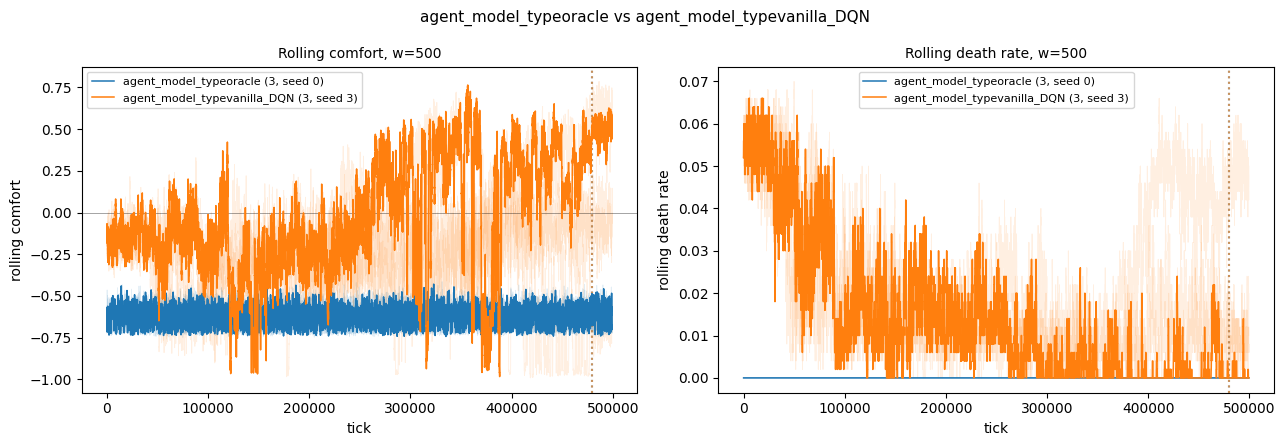

C:\Users\Adarsh Arun\AppData\Local\Temp\ipykernel_1944\3788852159.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


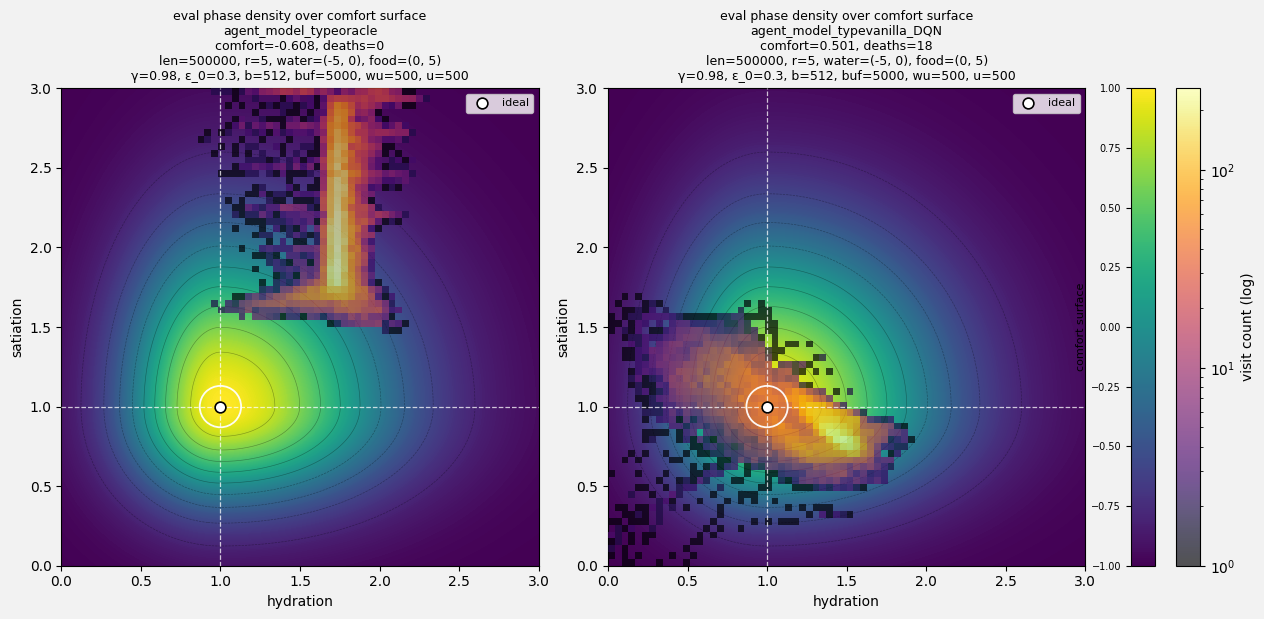

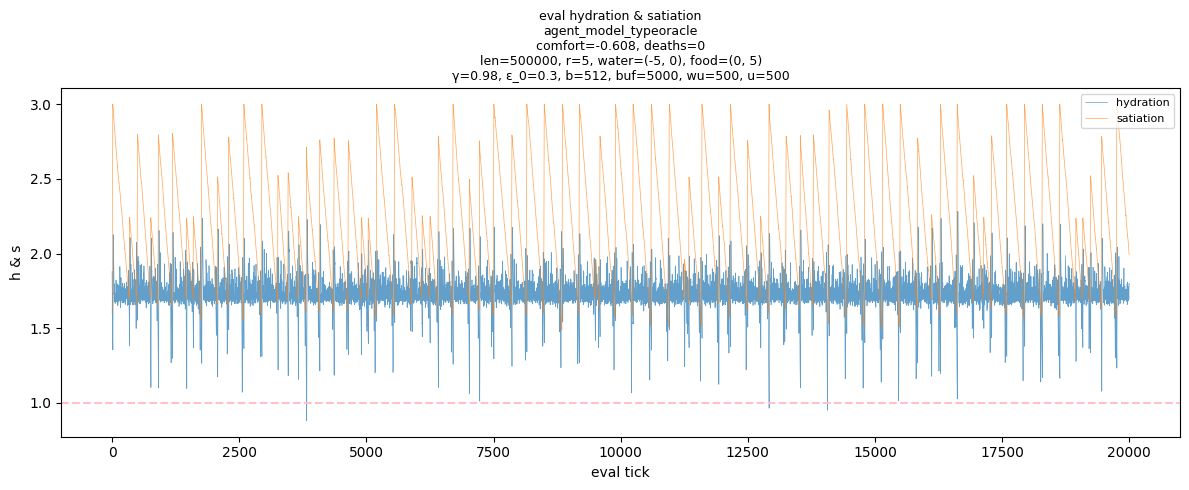

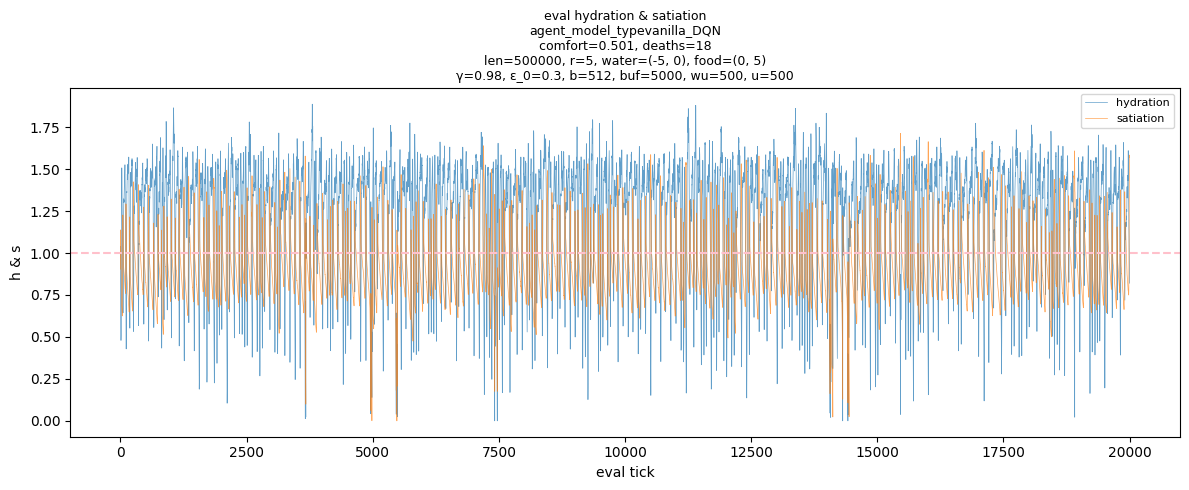

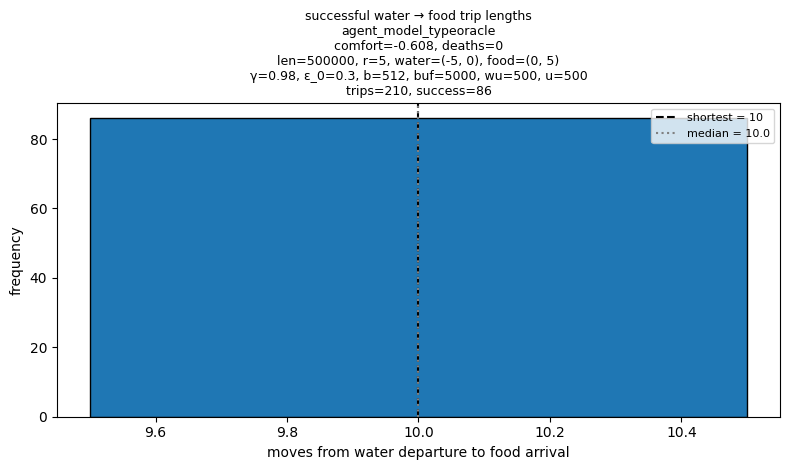

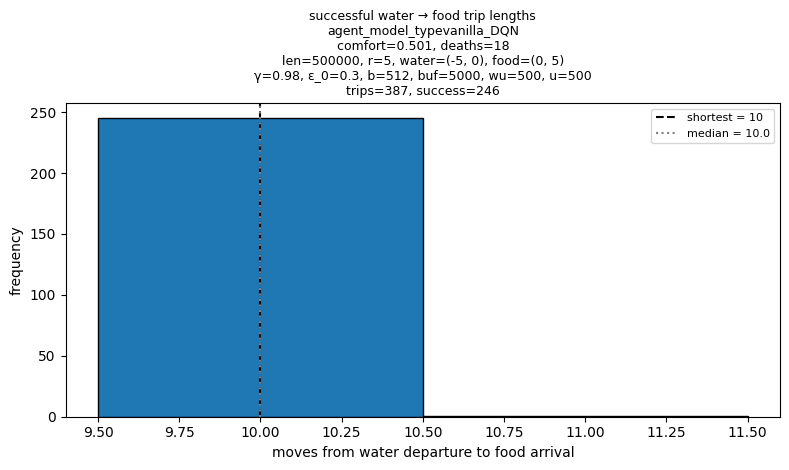

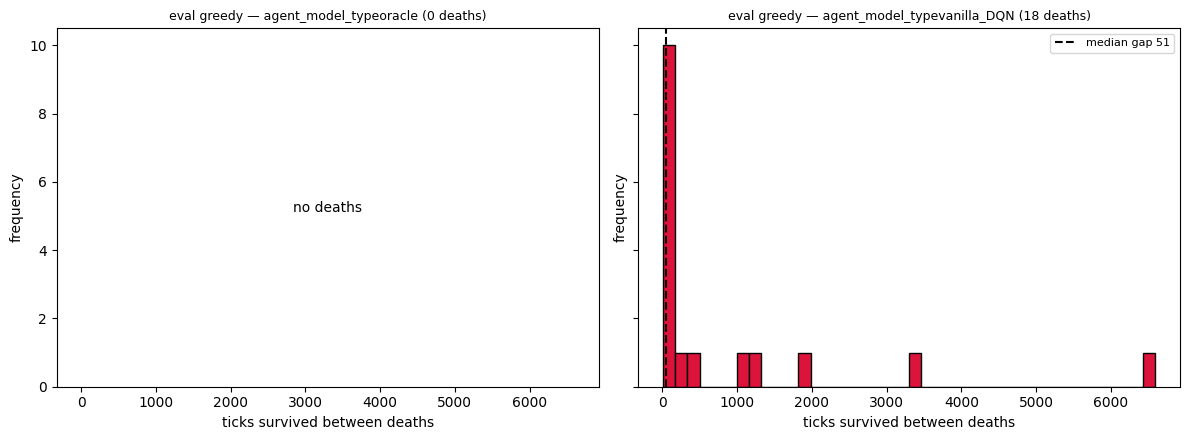

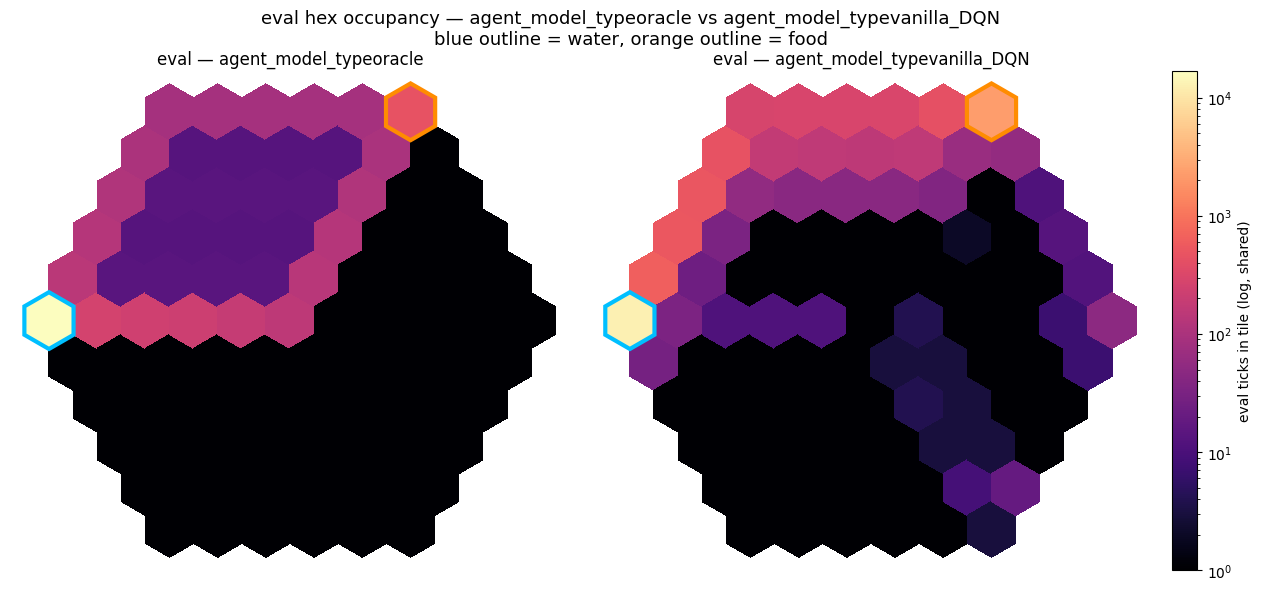

In [13]:
#region PLOT COMPARISON

def print_available_configs():
    print("available configs:")

    for i, name in enumerate(res.keys()):
        ranked = res[name]["ranked"]
        median = res[name]["median"]

        print(
            f"{i}: {name} | "
            f"n={len(ranked)} | "
            f"median comfort={median['mean_comfort']:.3f} | "
            f"median-run deaths={median['death_count_eval']}"
        )

def choose_configs():
    names = list(res.keys())

    print_available_configs()
    sel = input("Select runs, comma-separated e.g. 0,1: ")

    idxs = [int(x.strip()) for x in sel.split(",") if x.strip() != ""]

    if len(idxs) < 1:
        raise ValueError("Select at least one config.")

    for i in idxs:
        if i < 0 or i >= len(names):
            raise IndexError(f"Config index out of range: {i}")

    return [names[i] for i in idxs]


NAMES = choose_configs()
PICK = 3



def rolling_mean(x, window):
    x = np.asarray(x, dtype=float)

    if window <= 0:
        raise ValueError("window must be positive")

    if len(x) < window:
        return np.array([])

    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[window:] - c[:-window]) / window


def draw_rolling(ax, series, key, window, ymarks=()):
    # background seed haze
    for s in series:
        for run in s["bg"]:
            ax.plot(
                rolling_mean(run[key], window),
                color=s["haze"],
                lw=0.6,
                alpha=0.12,
                zorder=1,
            )

    # selected representative run
    for s in series:
        run = s["run"]
        ax.plot(
            rolling_mean(run[key], window),
            color=s["color"],
            lw=1.1,
            zorder=3,
            label=s["label"],
        )

        eb_roll = max(0, eb_of(run) - window + 1)
        ax.axvline(
            eb_roll,
            ls=":",
            c=s["color"],
            alpha=0.6,
            zorder=2,
        )

    for y in ymarks:
        ax.axhline(y, ls="-", c="black", lw=0.5, alpha=0.5)

    ax.legend(fontsize=8)


def safe_fig_name(prefix, names):
    joined = "_vs_".join(names)
    joined = joined.replace(" ", "_").replace("/", "-").replace("\\", "-")
    return f"{prefix}_{joined}"


def build_comparison_series(names, pick, colors):
    picked = [(name, pick_run(name, pick=pick)) for name in names]

    series = []
    for i, (name, run) in enumerate(picked):
        color = colors[i % len(colors)]
        haze = color if len(picked) > 1 else "gray"

        series.append({
            "bg": res[name]["ranked"],
            "run": run,
            "color": color,
            "haze": haze,
            "label": f"{name} ({pick}, seed {run['seed']})",
        })

    return picked, series


def plot_comparison(
    names,
    pick="median",
    window=500,
    save=False,
    colors=("tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"),
):
    picked, series = build_comparison_series(names, pick, colors)

    # rolling comfort + death rate
    fig, (ax_c, ax_d) = plt.subplots(1, 2, figsize=(13, 4.5))

    draw_rolling(ax_c, series, "comfort_T", window, ymarks=(0,))
    ax_c.set_title(f"Rolling comfort, w={window}", fontsize=10)
    ax_c.set_xlabel("tick")
    ax_c.set_ylabel("rolling comfort")

    draw_rolling(ax_d, series, "death_T", window)
    ax_d.set_title(f"Rolling death rate, w={window}", fontsize=10)
    ax_d.set_xlabel("tick")
    ax_d.set_ylabel("rolling death rate")

    fig.suptitle(" vs ".join(names), fontsize=11)
    plt.tight_layout()

    if save:
        _save_fig(fig, safe_fig_name("cmp_rolling", names))

    plt.show()

    # phase density
    from matplotlib.gridspec import GridSpec

    n = len(picked)
    fig = plt.figure(figsize=(6.8 * n + 1.4, 6.2))
    gs  = GridSpec(1, n + 2,
                width_ratios=[*([1] * n), 0.045, 0.045],
                wspace=0.08, figure=fig)

    plot_axes  = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax_surf   = fig.add_subplot(gs[0, n])
    cax_dens   = fig.add_subplot(gs[0, n + 1])

    surf_m = dens_m = None
    for (name, run), ax in zip(picked, plot_axes):
        s, d = plot_phase_heatmap(run, name=name, ax=ax)
        surf_m = surf_m or s
        dens_m = dens_m or d          # first non-None density scale wins

    cbar_s = fig.colorbar(surf_m, cax=cax_surf)
    cbar_s.ax.yaxis.set_ticks_position('left')
    cbar_s.ax.yaxis.set_label_position('left')
    cbar_s.set_label("comfort surface", fontsize=8)
    cbar_s.set_ticks(np.linspace(-1, 1, 9))
    cbar_s.ax.tick_params(labelsize=7)

    if dens_m is not None:
        cbar_d = fig.colorbar(dens_m, cax=cax_dens)
        cbar_d.set_label("visit count (log)")

    plt.tight_layout()
    plt.show()

    # per-run diagnostics
    for name, run in picked:
        plot_eval_hs(run, name=name, save=save)

    for name, run in picked:
        plot_trip_lengths(run, name=name, save=save)

    # comparison diagnostics
    plot_death_gaps_eval_compare(picked, save=save)
    plot_hex_eval_compare(picked, save=save)


plot_comparison(NAMES, pick=PICK, window=500)

#endregion

In [13]:
#region SUMMARY BLOCK

def fmt_pct(x, digits=1):
    if pd.isna(x):
        return "nan"
    return f"{100*x:.{digits}f}%"

def fmt_runtime(x):
    if pd.isna(x):
        return "nan"
    if "fmt_time" in globals():
        return fmt_time(x)
    return f"{x:.1f}s"

def fmt_num(x, digits=3):
    if pd.isna(x):
        return "nan"
    return f"{x:.{digits}f}"


def print_final_sweep_summary(summary_df, runs_df, experiment_name):
    if summary_df.empty:
        print("No summary data loaded.")
        return

    print("=" * 90)
    print(f"FINAL SWEEP SUMMARY: {experiment_name}")
    print("=" * 90)

    print("\nConfigs tested:")
    print(f"  configs: {summary_df['config'].nunique()}")
    print(f"  total runs: {len(runs_df)}")
    print(f"  seeds per config: {int(summary_df['n_seeds'].median())}")

    print("\nCompact summary table:")
    cols = [
        "config",
        "n_seeds",
        "sim_len",
        "run_time_seconds_median",
        #"seconds_per_100k_ticks_median",
        #"ticks_per_second_median",
        "mean_comfort_median",
        "mean_comfort_std",
        "eval_deaths_median",
        "zero_death_rate",
        "food_visit_pct_median",
        "water_visit_pct_median",
        "path_efficiency_median",
        "perfectish_trip_rate_median",
        "solved_rate",
    ]

    table = summary_df[cols].copy()

    table["mean_comfort_median"] = table["mean_comfort_median"].map(lambda x: round(x, 3))
    table["mean_comfort_std"] = table["mean_comfort_std"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["eval_deaths_median"] = table["eval_deaths_median"].map(lambda x: round(x, 1))
    table["zero_death_rate"] = table["zero_death_rate"].map(lambda x: f"{100*x:.0f}%")
    table["food_visit_pct_median"] = table["food_visit_pct_median"].map(lambda x: round(x, 1))
    table["water_visit_pct_median"] = table["water_visit_pct_median"].map(lambda x: round(x, 1))
    table["path_efficiency_median"] = table["path_efficiency_median"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["perfectish_trip_rate_median"] = table["perfectish_trip_rate_median"].map(lambda x: f"{100*x:.0f}%" if not pd.isna(x) else "nan")
    table["solved_rate"] = table["solved_rate"].map(lambda x: f"{100*x:.0f}%")
    table["run_time_seconds_median"] = table["run_time_seconds_median"].map(fmt_runtime)
    #table["seconds_per_100k_ticks_median"] = table["seconds_per_100k_ticks_median"].map(lambda x: round(x, 2) if not pd.isna(x) else np.nan)
    #table["ticks_per_second_median"] = table["ticks_per_second_median"].map(lambda x: round(x, 1) if not pd.isna(x) else np.nan)

    print(table.to_string(index=False))

    print("\n" + "-" * 90)
    print("Winners / notable configs")
    print("-" * 90)

    best_comfort = summary_df.sort_values(
        ["mean_comfort_median", "mean_comfort_std"],
        ascending=[False, True],
    ).iloc[0]

    best_stability = summary_df.sort_values(
        ["mean_comfort_std", "mean_comfort_median"],
        ascending=[True, False],
    ).iloc[0]

    best_deaths = summary_df.sort_values(
        ["zero_death_rate", "eval_deaths_median", "mean_comfort_median"],
        ascending=[False, True, False],
    ).iloc[0]

    best_path = summary_df.sort_values(
        ["path_efficiency_median", "perfectish_trip_rate_median", "mean_comfort_median"],
        ascending=[False, False, False],
    ).iloc[0]

    best_solved = summary_df.sort_values(
        ["solved_rate", "mean_comfort_median", "path_efficiency_median"],
        ascending=[False, False, False],
    ).iloc[0]

    #best_runtime_efficiency = summary_df.sort_values(
    #["seconds_per_100k_ticks_median", "mean_comfort_median"],
    #ascending=[True, False],
    #).iloc[0]

    print(f"\nBest median comfort:")
    print(f"  {best_comfort['config']}")
    print(f"  median comfort = {best_comfort['mean_comfort_median']:.3f}")
    print(f"  std comfort    = {best_comfort['mean_comfort_std']:.3f}")

    print(f"\nMost stable comfort:")
    print(f"  {best_stability['config']}")
    print(f"  std comfort    = {best_stability['mean_comfort_std']:.3f}")
    print(f"  median comfort = {best_stability['mean_comfort_median']:.3f}")

    print(f"\nBest death robustness:")
    print(f"  {best_deaths['config']}")
    print(f"  zero-death rate     = {100*best_deaths['zero_death_rate']:.0f}%")
    print(f"  median eval deaths  = {best_deaths['eval_deaths_median']:.1f}")

    print(f"\nBest path efficiency:")
    print(f"  {best_path['config']}")
    print(f"  path efficiency        = {best_path['path_efficiency_median']:.3f}")
    print(f"  perfect-ish trip rate  = {100*best_path['perfectish_trip_rate_median']:.0f}%")

    print(f"\nBest overall solved rate:")
    print(f"  {best_solved['config']}")
    print(f"  solved rate      = {100*best_solved['solved_rate']:.0f}%")
    print(f"  median comfort   = {best_solved['mean_comfort_median']:.3f}")
    print(f"  path efficiency  = {best_solved['path_efficiency_median']:.3f}")
    print(f"\nBest runtime efficiency:")
    #print(f"  {best_runtime_efficiency['config']}")
    #print(f"  seconds per 100k      = {best_runtime_efficiency['seconds_per_100k_ticks_median']:.2f}")
    #print(f"  median comfort        = {best_runtime_efficiency['mean_comfort_median']:.3f}")

    print("\n" + "-" * 90)
    print("Interpretation prompts")
    print("-" * 90)

    sim_lens = sorted(summary_df["sim_len"].dropna().unique())

    if len(sim_lens) > 1:
        print("\nTraining-length question:")
        print("  Did longer training improve median comfort, reduce seed variance, or sharpen path efficiency?")

        length_view = summary_df.sort_values("sim_len")[
            [
                "config",
                "sim_len",
                "mean_comfort_median",
                "mean_comfort_std",
                "zero_death_rate",
                "path_efficiency_median",
                "perfectish_trip_rate_median",
                #"seconds_per_100k_ticks_median",
                "solved_rate",
            ]
        ].copy()

        length_view["mean_comfort_median"] = length_view["mean_comfort_median"].round(3)
        length_view["mean_comfort_std"] = length_view["mean_comfort_std"].round(3)
        length_view["zero_death_rate"] = (100 * length_view["zero_death_rate"]).round(0).astype(int).astype(str) + "%"
        length_view["path_efficiency_median"] = length_view["path_efficiency_median"].round(3)
        length_view["perfectish_trip_rate_median"] = (100 * length_view["perfectish_trip_rate_median"]).round(0).astype("Int64").astype(str) + "%"
        length_view["solved_rate"] = (100 * length_view["solved_rate"]).round(0).astype(int).astype(str) + "%"

        print()
        print(length_view.to_string(index=False))

    print("\nEvidence statement draft:")
    print(
        "  This sweep compares configs across multiple seeds using median comfort, death robustness, "
        "resource visitation, and water-to-food route efficiency. A config is strongest only if it "
        "improves performance without relying on one lucky seed."
    )

    print("\nSaved files:")
    out = sweep_dir(experiment_name)
    print(f"  runs CSV:    {out / 'runs_df.csv'}")
    print(f"  summary CSV: {out / 'summary_df.csv'}")


print_final_sweep_summary(summary_df, runs_df, EXPERIMENT_NAME)

#endregion

FINAL SWEEP SUMMARY: ORACLE VS VANILLA_DQN with 3max

Configs tested:
  configs: 2
  total runs: 10
  seeds per config: 5

Compact summary table:
                     config  n_seeds  sim_len run_time_seconds_median  mean_comfort_median  mean_comfort_std  eval_deaths_median zero_death_rate  food_visit_pct_median  water_visit_pct_median  path_efficiency_median perfectish_trip_rate_median solved_rate
agent_model_typevanilla_DQN        5   500000                  2m 12s                -0.03             0.513               198.0              0%                    9.3                    63.4                     1.0                         97%          0%
     agent_model_typeoracle        5   500000                     20s                -0.61             0.002                 0.0            100%                    2.2                    84.5                     1.0                        100%          0%

-------------------------------------------------------------------------------------

In [33]:
#region SINGLE RUN — check whether Double DQN reaches actual food tile
# this exists because i forgot gamma=0.98 is what let me get nicer results

SEED = 0
MODEL_TYPE = "double_DQN"

ENV_KWARGS = dict(
    radius=5,
    water_coord=(-5, 0),
    food_coord=(0, 5),
)

print("Running one fresh sim...")
print("model:", MODEL_TYPE)
print("seed:", SEED)
print("env:", ENV_KWARGS)

run = sim_instance(
    seed=SEED,
    model_type=MODEL_TYPE,
    sim_len=500_000,
    eval_len=20_000,
    gamma=0.98,
    env_kwargs=ENV_KWARGS,
    debug_diet_cause=True
)

coords_eval = np.asarray(run["coordinates_eval"]).astype(int)
coords_all = np.asarray(run["coordinates_T"]).astype(int)

food = tuple(ENV_KWARGS["food_coord"])
water = tuple(ENV_KWARGS["water_coord"])

visited_eval = set(map(tuple, coords_eval))
visited_all = set(map(tuple, coords_all))

food_ticks_eval = int(np.all(coords_eval == np.array(food), axis=1).sum())
water_ticks_eval = int(np.all(coords_eval == np.array(water), axis=1).sum())

food_ticks_all = int(np.all(coords_all == np.array(food), axis=1).sum())
water_ticks_all = int(np.all(coords_all == np.array(water), axis=1).sum())

# axial hex neighbours
HEX_DIRS = [(1, 0), (1, -1), (0, -1), (-1, 0), (-1, 1), (0, 1)]

def hex_neighbours(coord):
    q, r = coord
    return [(q + dq, r + dr) for dq, dr in HEX_DIRS]

food_neighbours = set(hex_neighbours(food))
water_neighbours = set(hex_neighbours(water))

food_neighbour_hits_eval = visited_eval & food_neighbours
water_neighbour_hits_eval = visited_eval & water_neighbours

print("\nRESULTS")
print("mean comfort:", run["mean_comfort"])
print("eval deaths:", run["death_count_eval"])

print("\nFOOD CHECK")
print("actual food coord:", food)
print("food visited in eval:", food in visited_eval)
print("ticks on food in eval:", food_ticks_eval)
print("ticks on food in full run:", food_ticks_all)
print("food neighbours visited in eval:", sorted(food_neighbour_hits_eval))
print("number of food neighbours visited in eval:", len(food_neighbour_hits_eval))

print("\nWATER CHECK")
print("actual water coord:", water)
print("water visited in eval:", water in visited_eval)
print("ticks on water in eval:", water_ticks_eval)
print("ticks on water in full run:", water_ticks_all)
print("water neighbours visited in eval:", sorted(water_neighbour_hits_eval))
print("number of water neighbours visited in eval:", len(water_neighbour_hits_eval))

print("\nCOVERAGE")
print("unique tiles visited in eval:", len(visited_eval))
print("unique tiles visited in full run:", len(visited_all))
print("max q eval, max r eval:", coords_eval[:, 0].max(), coords_eval[:, 1].max())
print("min q eval, min r eval:", coords_eval[:, 0].min(), coords_eval[:, 1].min())

#endregion

Running one fresh sim...
model: double_DQN
seed: 0
env: {'radius': 5, 'water_coord': (-5, 0), 'food_coord': (0, 5)}
DIET DEBUG ON

PRE-RESET FOOD DEBUG
t: 480172 eval_tick: 172
coord: (0, 4) food: (0, 5) dist: 1
h, s: 0.578 0.2809
cur_dead: 0 cur_reward: -0.7515
mask: [(np.int64(0), 'wait'), (np.int64(7), 'move_E'), (np.int64(8), 'move_NE'), (np.int64(9), 'move_NW'), (np.int64(10), 'move_W'), (np.int64(11), 'move_SW'), (np.int64(12), 'move_SE')]

FOOD DEBUG
t: 480172 eval_tick: 172
coord: (0, 4) food: (0, 5) dist: 1
h, s: 0.578 0.2809
valid actions: [(0, 'wait'), (7, 'move_E'), (8, 'move_NE'), (9, 'move_NW'), (10, 'move_W'), (11, 'move_SW'), (12, 'move_SE')]
chosen greedy: 9 move_NW
eat valid?: {'eat_full': False, 'eat_half': False, 'eat_quarter': False}
eat Qs: {'eat_full': -37.2487, 'eat_half': -53.23, 'eat_quarter': -38.6613}
top masked Qs: [(9, 'move_NW', -34.0427), (0, 'wait', -35.1839), (7, 'move_E', -36.4018), (8, 'move_NE', -40.8185), (12, 'move_SE', -42.8586), (10, 'move_W', -

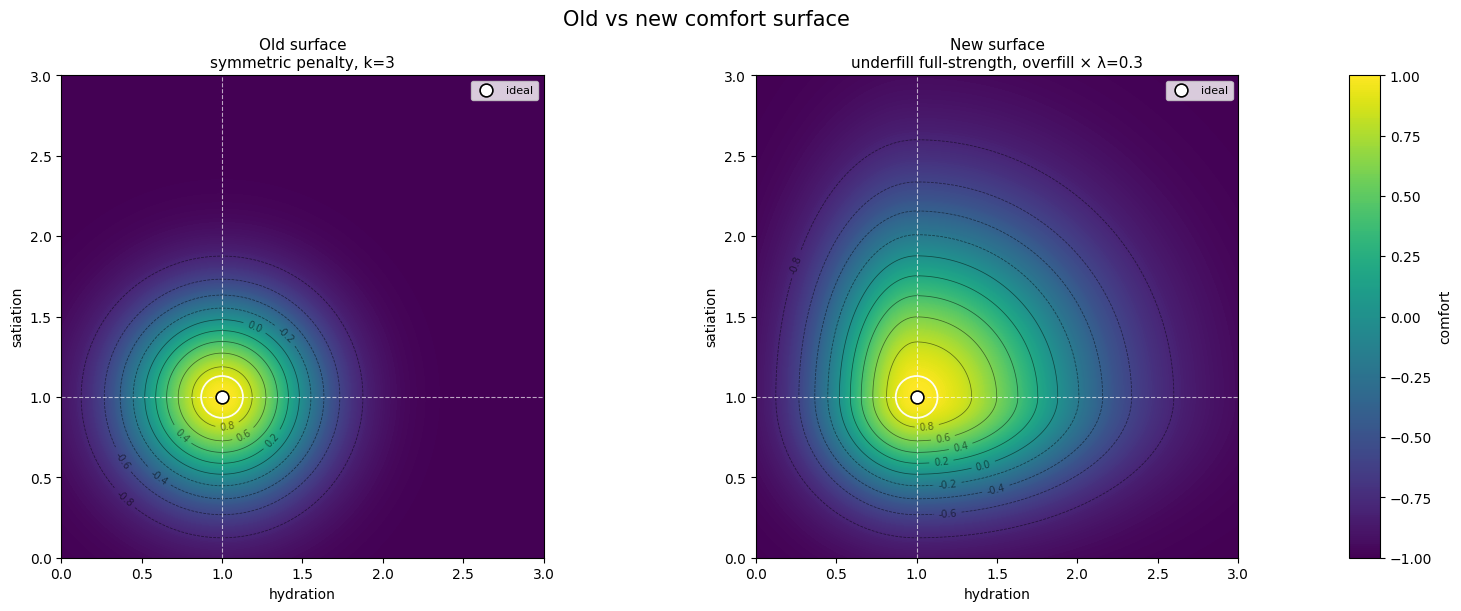

In [14]:
import numpy as np
from matplotlib.colors import Normalize

# --- tweak these if needed ---
ideal_h = 1.0
ideal_s = 1.0

hs_max = 3.0
n = 300

old_k = 3
new_k = 3.0
lam_over = 0.3

# --- old comfort surface ---
def comfort_old(h, s, ideal_h=1.0, ideal_s=1.0, k=2.0):
    dh = h - ideal_h
    ds = s - ideal_s
    d2 = dh**2 + ds**2
    return 2 * np.exp(-k * d2) - 1

# --- new comfort surface ---
def comfort_new(h, s, ideal_h=1.0, ideal_s=1.0, k=2.0, lam_over=0.3):
    dh = h - ideal_h
    ds = s - ideal_s

    h_over = np.maximum(0, dh)
    h_under = np.minimum(0, dh)

    s_over = np.maximum(0, ds)
    s_under = np.minimum(0, ds)

    d2 = h_under**2 + lam_over * h_over**2 + s_under**2 + lam_over * s_over**2
    return 2 * np.exp(-k * d2) - 1

# --- grid ---
h_vals = np.linspace(0, hs_max, n)
s_vals = np.linspace(0, hs_max, n)
H, S = np.meshgrid(h_vals, s_vals)

Z_old = comfort_old(H, S, ideal_h=ideal_h, ideal_s=ideal_s, k=old_k)
Z_new = comfort_new(H, S, ideal_h=ideal_h, ideal_s=ideal_s, k=new_k, lam_over=lam_over)

# clamp tiny floating error so colourbar/levels behave cleanly
Z_old = np.clip(Z_old, -1, 1)
Z_new = np.clip(Z_new, -1, 1)

# hardcoded shared colour scale
norm = Normalize(vmin=-1, vmax=1)
levels_fill = np.linspace(-1, 1, 240)
levels_line = np.linspace(-1, 1, 11)

# dedicated colourbar axis so it doesn't sit inside the second plot
fig = plt.figure(figsize=(15, 6), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.045])

ax_old = fig.add_subplot(gs[0, 0])
ax_new = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

fig.suptitle("Old vs new comfort surface", fontsize=15)

plots = [
    (ax_old, Z_old, f"Old surface\nsymmetric penalty, k={old_k}"),
    (ax_new, Z_new, f"New surface\nunderfill full-strength, overfill × λ={lam_over}"),
]

for ax, Z, title in plots:
    cf = ax.contourf(
        H, S, Z,
        levels=levels_fill,
        cmap="viridis",
        norm=norm,
        extend="neither"
    )

    cs = ax.contour(
        H, S, Z,
        levels=levels_line,
        colors="black",
        linewidths=0.55,
        alpha=0.50
    )

    ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

    # ideal point
    ax.scatter(
        [ideal_h], [ideal_s],
        s=85,
        c="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=5,
        label="ideal"
    )

    # guide lines through ideal
    ax.axvline(ideal_h, linestyle="--", linewidth=0.8, alpha=0.65, color="white")
    ax.axhline(ideal_s, linestyle="--", linewidth=0.8, alpha=0.65, color="white")

    # subtle ideal ring
    ring = plt.Circle(
        (ideal_h, ideal_s),
        0.13,
        fill=False,
        color="white",
        linewidth=1.3,
        alpha=0.95,
        zorder=6
    )
    ax.add_patch(ring)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("hydration")
    ax.set_ylabel("satiation")
    ax.set_xlim(0, hs_max)
    ax.set_ylim(0, hs_max)
    ax.set_aspect("equal")
    ax.legend(fontsize=8, loc="upper right")

cbar = fig.colorbar(cf, cax=cax)
cbar.set_label("comfort")
cbar.set_ticks(np.linspace(-1, 1, 9))

plt.show()